# HAM10000 Preprocessing and Hybrid Bias-Reduction Framework

This notebook covers the first half of the FYP pipeline: importing and cleaning the HAM10000 metadata and images, exploring the dataset, and building the hybrid data-centric preprocessing framework used to reduce demographic bias ahead of model training.

The notebook is organised into three main sections:

1. **Data Import** — loading the HAM10000 metadata and images and running initial exploratory checks.
2. **Data Preprocessing** — cleaning missing/unknown values, resizing images, and visualising the cleaned dataset.
3. **Hybrid Data-Centric Preprocessing Framework** — intersectional stratified sampling, adaptive distribution-aware reweighting, and cGAN augmentation for the rarest demographic subgroups.

All dataset paths point to the Kaggle copy of HAM10000 (`kmader/skin-cancer-mnist-ham10000`), and the framework section continues directly from the cleaned dataframe produced during preprocessing rather than reloading the raw metadata.

## SECTION 1: Data Import

Loads the HAM10000 metadata and dermoscopic images and runs the initial exploratory checks before any cleaning is applied.

### Part A — Loading and Exploring the Dataset

### Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: make output easier to read
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 100)

### *** Set File Paths

In [3]:
# Metadata CSV path (Kaggle dataset)
metadata_path = Path("/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv")

# Image folder path
image_dir_part1 = Path("/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1")

# Part 2 image folder
image_dir_part2 = Path("/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2")

## EDA 1: Load and Inspect Dataset 

###  Load the Metadata CSV

In [ ]:
df = pd.read_csv(metadata_path)

print("Dataset successfully loaded.")
print("Shape of dataset:", df.shape)

Dataset loaded successfully.
Shape of dataset: (10015, 7)


### *** View the First Few Rows 

In [5]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


## EDA 2: Describe Variables 

### Check Data Types and Basic Info

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


###  *** Create a Variable Summary Table

In [7]:
summary_table = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Non-Null Count": df.notnull().sum().values,
    # "Missing Values": df.isnull().sum().values,
    # "Missing Percentage (%)": (df.isnull().sum().values / len(df) * 100).round(2),
    "Unique Values": [df[col].nunique(dropna=True) for col in df.columns]
})

summary_table

,Column,Data Type,Non-Null Count,Unique Values
0,lesion_id,object,10015,7470
1,image_id,object,10015,10015
2,dx,object,10015,7
3,dx_type,object,10015,4
4,age,float64,9958,18
5,sex,object,10015,3
6,localization,object,10015,15


###  Explain the Diagnosis Labels (dx)

In [8]:
dx_mapping = {
    "akiec": "Actinic keratoses / Bowen’s disease (intraepithelial carcinoma)",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis-like lesions",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevi",
    "vasc": "Vascular lesions"
}

dx_table = pd.DataFrame(list(dx_mapping.items()), columns=["Label Code", "Full Diagnosis Name"])
dx_table

,Label Code,Full Diagnosis Name
0,akiec,Actinic keratoses / Bowen’s disease (intraepithelial carcinoma)
1,bcc,Basal cell carcinoma
2,bkl,Benign keratosis-like lesions
3,df,Dermatofibroma
4,mel,Melanoma
5,nv,Melanocytic nevi
6,vasc,Vascular lesions


## EDA 3: Potential Issues 

### Frequency of Values in Key Categorical Columns

In [9]:
categorical_cols = ["dx", "dx_type", "age", "sex", "localization"]

for col in categorical_cols:
    print(f"\nValue counts for '{col}':")
    print(df[col].value_counts(dropna=False))


Value counts for 'dx':
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Value counts for 'dx_type':
dx_type
histo        5340
follow_up    3704
consensus     902
confocal       69
Name: count, dtype: int64

Value counts for 'age':
age
45.0    1299
50.0    1187
55.0    1009
40.0     985
60.0     803
70.0     756
35.0     753
65.0     731
75.0     618
30.0     464
80.0     404
85.0     290
25.0     247
20.0     169
5.0       86
15.0      77
NaN       57
10.0      41
0.0       39
Name: count, dtype: int64

Value counts for 'sex':
sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64

Value counts for 'localization':
localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
face                745
chest               407
foot                319
unknown             234
neck                168
scalp               12

###  Frequency Metrics for Age (Mean, Median, Mode)

In [10]:
df.describe()

,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


###  Check for Duplicate Records

In [11]:
print("Number of fully duplicated rows:", df.duplicated().sum())
print("Number of duplicated image_id:", df["image_id"].duplicated().sum())
print("Number of duplicated lesion_id:", df["lesion_id"].duplicated().sum())

Number of fully duplicated rows: 0
Number of duplicated image_id: 0
Number of duplicated lesion_id: 2545


###  Check for Suspicious / Dirty Values

In [12]:
# Check age issues
invalid_age = df[(df["age"] < 0) | (df["age"] > 120)]
missing_age = df[df["age"].isna()]

print("Invalid age rows:", len(invalid_age))
print("Missing age rows:", len(missing_age))

# Check unknown values in categorical columns
print("\nUnknown values in sex:")
print((df["sex"] == "unknown").sum())

print("\nUnknown values in localization:")
print((df["localization"] == "unknown").sum())

Invalid age rows: 0
Missing age rows: 57

Unknown values in sex:
57

Unknown values in localization:
234


## EDA 4: Checking Skin Lesion Images Quality

###  Collect all image files from both folders

In [13]:
image_files_part1 = list(image_dir_part1.glob("*.jpg"))
image_files_part2 = list(image_dir_part2.glob("*.jpg"))

all_image_files = image_files_part1 + image_files_part2

print("Images found in part 1:", len(image_files_part1))
print("Images found in part 2:", len(image_files_part2))
print("Total image files found:", len(all_image_files))

Images found in part 1: 5000
Images found in part 2: 5015
Total image files found: 10015


###  Create mapping from image_id to file path

In [14]:
image_path_map = {}

for img_path in all_image_files:
    image_id = img_path.stem
    image_path_map[image_id] = img_path

print("Total unique image IDs from image folders:", len(image_path_map))

Total unique image IDs from image folders: 10015


### Check whether metadata image IDs match the image files

In [15]:
metadata_image_ids = set(df["image_id"])
folder_image_ids = set(image_path_map.keys())

missing_in_folders = sorted(metadata_image_ids - folder_image_ids)
extra_in_folders = sorted(folder_image_ids - metadata_image_ids)

print("Image IDs in metadata:", len(metadata_image_ids))
print("Image IDs in folders:", len(folder_image_ids))
print("Missing image files:", len(missing_in_folders))
print("Extra image files not in metadata:", len(extra_in_folders))

Image IDs in metadata: 10015
Image IDs in folders: 10015
Missing image files: 0
Extra image files not in metadata: 0


### Show examples of missing or extra files

In [16]:
print("First 10 missing image IDs:", missing_in_folders[:10])
print("First 10 extra image IDs:", extra_in_folders[:10])

First 10 missing image IDs: []
First 10 extra image IDs: []


### Add image existence check to metadata

In [17]:
df["image_path"] = df["image_id"].map(image_path_map)
df["image_exists"] = df["image_path"].notnull()

print(df["image_exists"].value_counts())
df[["image_id", "image_exists"]].head()

image_exists
True    10015
Name: count, dtype: int64


,image_id,image_exists
0,ISIC_0027419,True
1,ISIC_0025030,True
2,ISIC_0026769,True
3,ISIC_0025661,True
4,ISIC_0031633,True


### Check for corrupted or unreadable images

In [18]:

corrupted_images = []
verified_images = 0

for image_id, img_path in image_path_map.items():
    try:
        with Image.open(img_path) as img:
            img.verify()
        verified_images += 1
    except (UnidentifiedImageError, OSError, IOError) as e:
        corrupted_images.append((image_id, str(e)))

print("Images successfully verified:", verified_images)
print("Corrupted/unreadable images:", len(corrupted_images))

Images successfully verified: 10015
Corrupted/unreadable images: 0


### Show corrupted images if any

In [19]:
corrupted_images[:10]

[]

### Read image properties (size, mode, format)

In [20]:
image_info = []

for image_id, img_path in image_path_map.items():
    try:
        with Image.open(img_path) as img:
            image_info.append({
                "image_id": image_id,
                "width": img.width,
                "height": img.height,
                "mode": img.mode,
                "format": img.format
            })
    except Exception:
        pass

image_info_df = pd.DataFrame(image_info)
image_info_df.head()

,image_id,width,height,mode,format
0,ISIC_0028933,600,450,RGB,JPEG
1,ISIC_0028394,600,450,RGB,JPEG
2,ISIC_0027799,600,450,RGB,JPEG
3,ISIC_0028100,600,450,RGB,JPEG
4,ISIC_0027960,600,450,RGB,JPEG


####  Summarize image sizes, modes, and formats

In [21]:
print("Unique image sizes:")
print(image_info_df[["width", "height"]].value_counts().head(10))

print("\nImage modes:")
print(image_info_df["mode"].value_counts(dropna=False))

print("\nImage formats:")
print(image_info_df["format"].value_counts(dropna=False))

Unique image sizes:
width  height
600    450       10015
Name: count, dtype: int64

Image modes:
mode
RGB    10015
Name: count, dtype: int64

Image formats:
format
JPEG    10015
Name: count, dtype: int64


### Check size consistency

In [22]:
size_counts = image_info_df.groupby(["width", "height"]).size().reset_index(name="count")
size_counts = size_counts.sort_values(by="count", ascending=False)

size_counts

,width,height,count
0,600,450,10015


###  Merge image properties back into metadata

In [23]:
df = df.merge(image_info_df, on="image_id", how="left")
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path,image_exists,width,height,mode,format
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027419.jpg,True,600,450,RGB,JPEG
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0025030.jpg,True,600,450,RGB,JPEG
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0026769.jpg,True,600,450,RGB,JPEG
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0025661.jpg,True,600,450,RGB,JPEG
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2/ISIC_0031633.jpg,True,600,450,RGB,JPEG


### Final image verification summary

In [24]:
verification_summary = pd.DataFrame({
    "Check": [
        "Total metadata records",
        "Total unique image IDs in metadata",
        "Total image files found in folders",
        "Missing image files",
        "Extra image files not in metadata",
        "Corrupted/unreadable image files",
        "Unique image sizes",
        "Unique image modes",
        "Unique image formats"
    ],
    "Result": [
        len(df),
        df["image_id"].nunique(),
        len(image_path_map),
        len(missing_in_folders),
        len(extra_in_folders),
        len(corrupted_images),
        image_info_df[["width", "height"]].drop_duplicates().shape[0],
        image_info_df["mode"].nunique(),
        image_info_df["format"].nunique()
    ]
})

verification_summary

,Check,Result
0,Total metadata records,10015
1,Total unique image IDs in metadata,10015
2,Total image files found in folders,10015
3,Missing image files,0
4,Extra image files not in metadata,0
5,Corrupted/unreadable image files,0
6,Unique image sizes,1
7,Unique image modes,1
8,Unique image formats,1


## SECTION 2: Data Preprocessing

Cleans the missing and unknown values identified during Section 1, resizes all images to 224x224, and visualises the cleaned dataset.

### Part B — Data Preprocessing

###  *** Metrics Before Preprocessing

In [25]:
missing_age_before = df['age'].isnull().sum()
unknown_sex_before = (df['sex'] == 'unknown').sum()
unknown_loc_before = (df['localization'] == 'unknown').sum()

print("--- BEFORE PRE-PROCESSING ---")
print(f"Missing age values: {missing_age_before}")
print(f"'unknown' sex values: {unknown_sex_before}")
print(f"'unknown' localization values: {unknown_loc_before}\n")

--- BEFORE PRE-PROCESSING ---
Missing age values: 57
'unknown' sex values: 57
'unknown' localization values: 234



###  Missing values in the age column (Median Imputation)

In [26]:
df_clean = df.copy()

# 1. Implementing Median Imputation for missing 'age' values
median_age = df_clean['age'].median()
df_clean['age'] = df_clean['age'].fillna(median_age)
print("Median imputation completed for 'age' column.")

Median imputation completed for 'age' column.


###  Unknown values in the sex column (Mode Imputation)

In [27]:
# Converting unknown values to NaN/ Missing
df_clean['sex'] = df_clean['sex'].replace('unknown', np.nan)

# Implementing Mode Imputation for 'sex' column
mode_sex = df_clean['sex'].mode()[0]
df_clean['sex'] = df_clean['sex'].fillna(mode_sex)
print("Mode imputation completed for 'sex' column.")

Mode imputation completed for 'sex' column.


###  Unknown values in the localization column (Mode Imputation)

In [28]:
# Converting unknown values to NaN/ Missing
df_clean['localization'] = df_clean['localization'].replace('unknown', np.nan)

# Implementing Mode Imputation for 'localization' column
mode_loc = df_clean['localization'].mode()[0]
df_clean['localization'] = df_clean['localization'].fillna(mode_loc)
print("Mode imputation completed for 'localization' column.")

Mode imputation completed for 'localization' column.


###  Image Resizing

####  Import libraries

In [29]:
from pathlib import Path
from PIL import Image, UnidentifiedImageError
import pandas as pd
import os

####  Set paths

In [30]:
# Output folder for resized images (Kaggle working directory)
output_dir = Path("/kaggle/working/HAM10000_images_resized_224x224")
output_dir.mkdir(parents=True, exist_ok=True)

print("Output folder ready:", output_dir)

Output folder ready: /kaggle/working/HAM10000_images_resized_224x224


#### Load metadata

In [31]:
df_meta = pd.read_csv(metadata_path)

print("Metadata loaded successfully.")
print("Shape:", df_meta.shape)
df_meta.head()

Metadata loaded successfully.
Shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


####  Build image path lookup

In [32]:
# Collect all JPG files from both source folders
image_files_part1 = list(image_dir_part1.glob("*.jpg"))
image_files_part2 = list(image_dir_part2.glob("*.jpg"))
all_image_files = image_files_part1 + image_files_part2

# Create mapping: image_id -> full path
image_path_map = {img_path.stem: img_path for img_path in all_image_files}

print("Images found in part 1:", len(image_files_part1))
print("Images found in part 2:", len(image_files_part2))
print("Total image files found:", len(all_image_files))
print("Total unique image IDs mapped:", len(image_path_map))

Images found in part 1: 5000
Images found in part 2: 5015
Total image files found: 10015
Total unique image IDs mapped: 10015


#### Resize images to 244x244

In [33]:
target_size = (224, 224)

resized_count = 0
missing_images = []
corrupted_images = []

for image_id in df_meta["image_id"]:
    img_path = image_path_map.get(image_id)
    
    if img_path is None:
        missing_images.append(image_id)
        continue

    try:
        with Image.open(img_path) as img:
            # Convert to RGB to ensure consistent 3-channel images
            img = img.convert("RGB")
            
            # Resize image
            img_resized = img.resize(target_size, Image.Resampling.LANCZOS)
            
            # Save resized image to new folder
            save_path = output_dir / f"{image_id}.jpg"
            img_resized.save(save_path, format="JPEG", quality=95)
            
            resized_count += 1

    except (UnidentifiedImageError, OSError, IOError) as e:
        corrupted_images.append((image_id, str(e)))

print("Resizing completed.")
print("Images resized successfully:", resized_count)
print("Missing images:", len(missing_images))
print("Corrupted/unreadable images:", len(corrupted_images))

Resizing completed.
Images resized successfully: 10015
Missing images: 0
Corrupted/unreadable images: 0


####  Check resized image size, mode and format

In [34]:
sample_info = []

for image_file in list(output_dir.glob("*.jpg"))[:10]:
    with Image.open(image_file) as img:
        sample_info.append({
            "image_id": image_file.stem,
            "width": img.width,
            "height": img.height,
            "mode": img.mode,
            "format": img.format
        })

pd.DataFrame(sample_info)

,image_id,width,height,mode,format
0,ISIC_0032681,224,224,RGB,JPEG
1,ISIC_0032522,224,224,RGB,JPEG
2,ISIC_0027133,224,224,RGB,JPEG
3,ISIC_0024593,224,224,RGB,JPEG
4,ISIC_0029662,224,224,RGB,JPEG
5,ISIC_0034024,224,224,RGB,JPEG
6,ISIC_0028323,224,224,RGB,JPEG
7,ISIC_0033354,224,224,RGB,JPEG
8,ISIC_0032329,224,224,RGB,JPEG
9,ISIC_0029913,224,224,RGB,JPEG


#### Verify all resized images have the correct size

In [ ]:
resized_image_files = list(output_dir.glob("*.jpg"))

size_check = []
for image_file in resized_image_files[:100]:  # checking first 100
    with Image.open(image_file) as img:
        size_check.append((img.width, img.height))

print("Unique sizes found in checked resized images:", set(size_check))

Unique sizes found in checked resized images: {(224, 224)}


---

###  Metrics After Preprocessing

In [36]:
missing_age_after = df_clean['age'].isnull().sum()
unknown_sex_after = df_clean['sex'].isnull().sum() + (df_clean['sex'] == 'unknown').sum()
unknown_loc_after = df_clean['localization'].isnull().sum() + (df_clean['localization'] == 'unknown').sum()

print("--- AFTER PRE-PROCESSING ---")
print(f"Missing 'age' values: {missing_age_after}")
print(f"'unknown' or missing 'sex' values: {unknown_sex_after}")
print(f"'unknown' or missing 'localization' values: {unknown_loc_after}")

--- AFTER PRE-PROCESSING ---
Missing 'age' values: 0
'unknown' or missing 'sex' values: 0
'unknown' or missing 'localization' values: 0


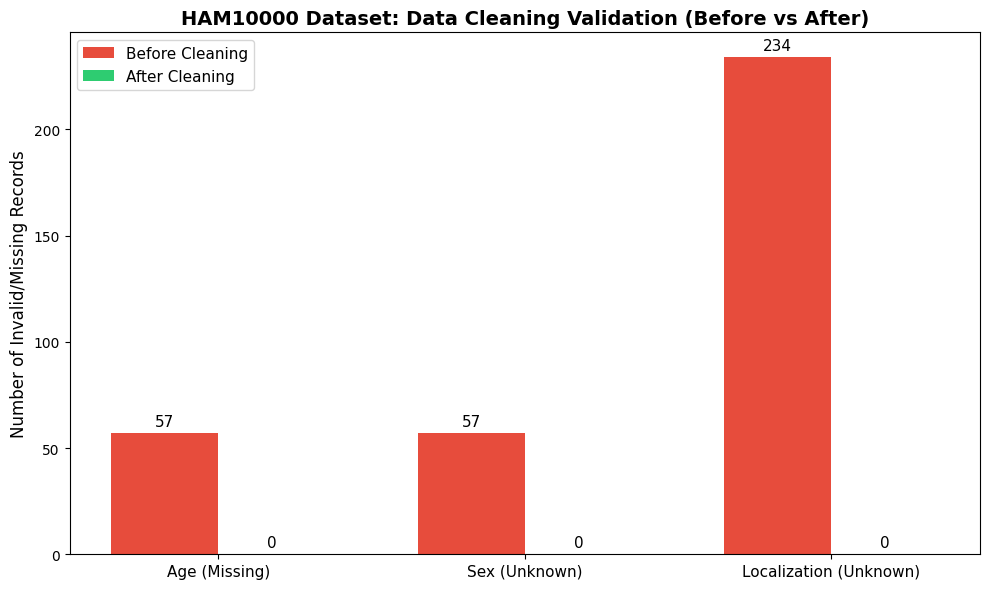

In [ ]:
# Set up  data
labels = ['Age (Missing)', 'Sex (Unknown)', 'Localization (Unknown)']
before_counts = [missing_age_before, unknown_sex_before, unknown_loc_before]
after_counts = [missing_age_after, unknown_sex_after, unknown_loc_after]

x = np.arange(len(labels))  # the label locations
width = 0.35  

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, before_counts, width, label='Before Cleaning', color='#e74c3c')
rects2 = ax.bar(x + width/2, after_counts, width, label='After Cleaning', color='#2ecc71')

# Add text for labels, title and custom x-axis 
ax.set_ylabel('Number of Invalid/Missing Records', fontsize=12)
ax.set_title('HAM10000 Dataset: Data Cleaning Validation (Before vs After)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=11)

# Display height of each bar
ax.bar_label(rects1, padding=3, fontsize=11)
ax.bar_label(rects2, padding=3, fontsize=11)

plt.tight_layout()
plt.show()

### Visualization of Successful Image Resizing

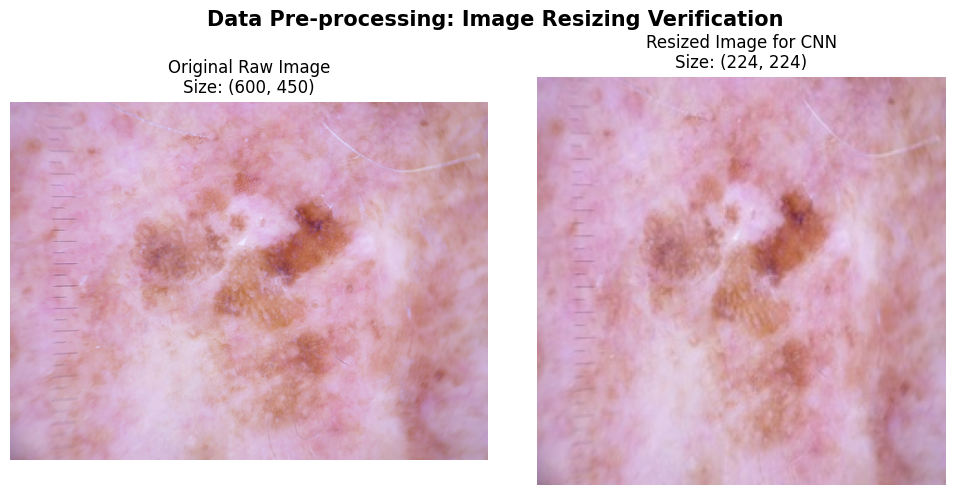

In [ ]:

# Before vs. After Image Resizing


# Select the first image_id from the metadata
sample_id = df_meta["image_id"].iloc[0]

# Original image path from the raw dataset
raw_img_path = image_path_map[sample_id]

# Resized image path from the output folder
resized_img_path = output_dir / f"{sample_id}.jpg"

# Open both images
raw_img = Image.open(raw_img_path)
resized_img = Image.open(resized_img_path)

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original raw image
axes[0].imshow(raw_img)
axes[0].set_title(f"Original Raw Image\nSize: {raw_img.size}", fontsize=12)
axes[0].axis("off")

# Resized image
axes[1].imshow(resized_img)
axes[1].set_title(f"Resized Image for CNN\nSize: {resized_img.size}", fontsize=12)
axes[1].axis("off")

plt.suptitle("Data Pre-processing: Image Resizing Verification", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## Part C - Data Visualization & Understanding

## Observations (Variables after cleaning)

In [39]:
categorical_cols = ["dx", "dx_type", "age", "sex", "localization"]

for col in categorical_cols:
    print(f"\nValue counts for '{col}':")
    print(df_clean[col].value_counts(dropna=False))


Value counts for 'dx':
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Value counts for 'dx_type':
dx_type
histo        5340
follow_up    3704
consensus     902
confocal       69
Name: count, dtype: int64

Value counts for 'age':
age
45.0    1299
50.0    1244
55.0    1009
40.0     985
60.0     803
70.0     756
35.0     753
65.0     731
75.0     618
30.0     464
80.0     404
85.0     290
25.0     247
20.0     169
5.0       86
15.0      77
10.0      41
0.0       39
Name: count, dtype: int64

Value counts for 'sex':
sex
male      5463
female    4552
Name: count, dtype: int64

Value counts for 'localization':
localization
back               2426
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
face                745
chest               407
foot                319
neck                168
scalp               128
hand                 90
ear                  56
genit

###  Visualization Graphs & Charts

#### Loading Library & Setting up

In [ ]:

%matplotlib inline 

import matplotlib.pyplot as plt
import seaborn as sns

# Global visual style for the plots
sns.set_theme(style="whitegrid")
palette = "viridis"

print("Libraries loaded and visual theme set successfully!")

Libraries loaded and visual theme set successfully!


#### Target Variable: Diagnosis Class (dx) - Bar Chart

/tmp/ipykernel_131/2418666822.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clean, x='dx',


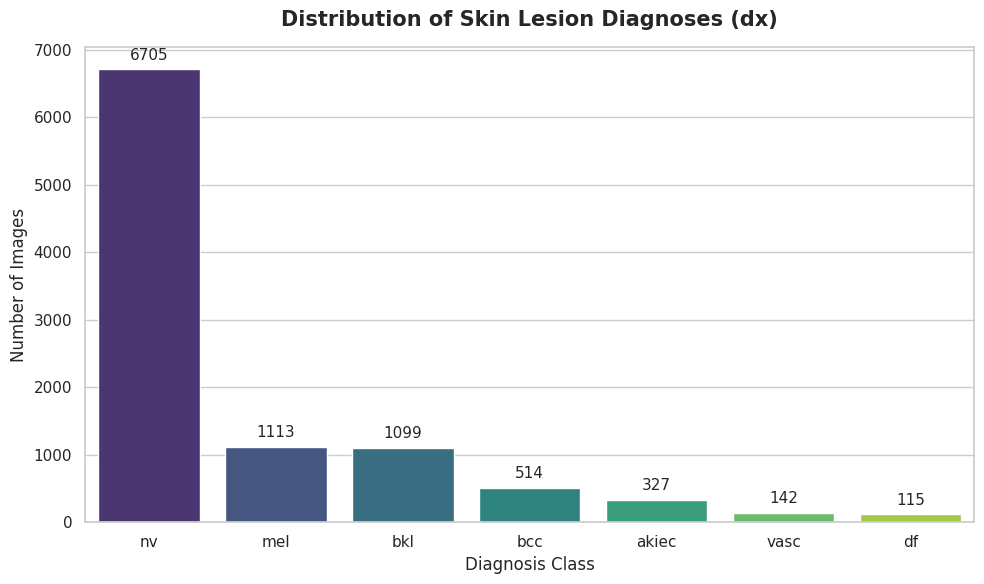

In [41]:

plt.figure(figsize=(10, 6))

ax = sns.countplot(data=df_clean, x='dx', 
                   order=df_clean['dx'].value_counts().index, 
                   palette=palette)

plt.title('Distribution of Skin Lesion Diagnoses (dx)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Diagnosis Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

    

#### Tree Map Chart

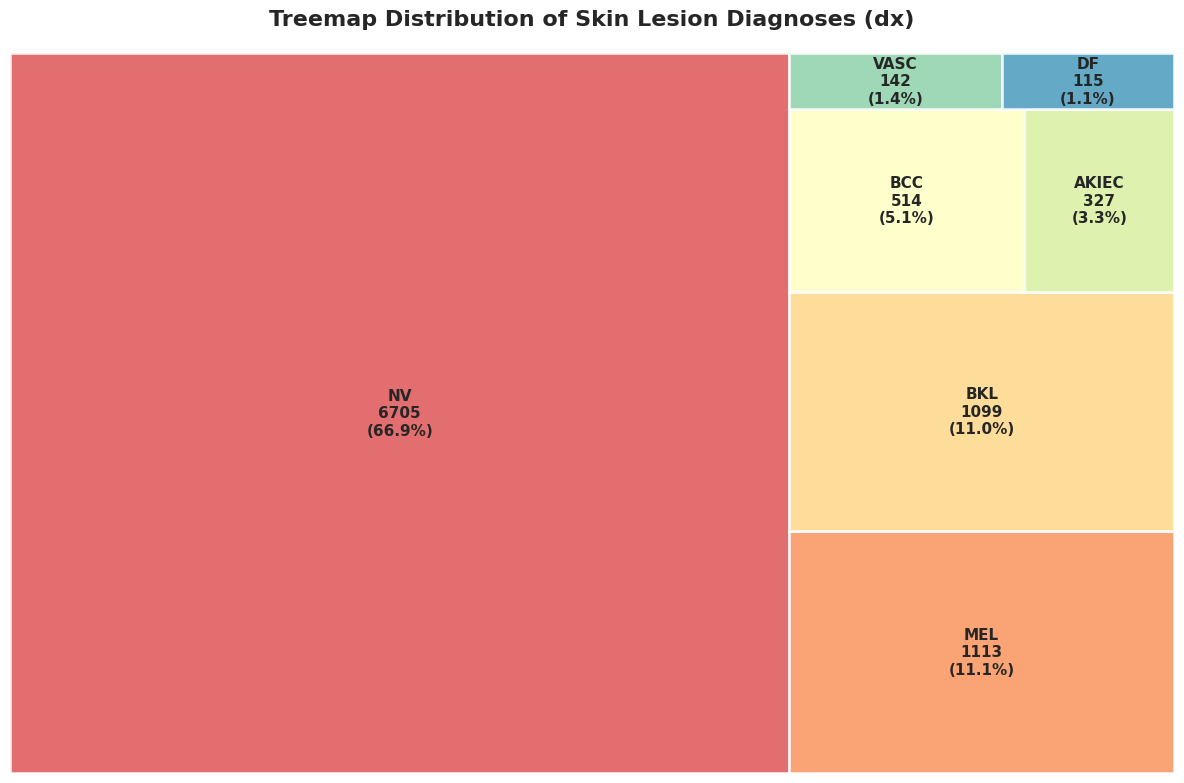

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
!pip install squarify
import squarify  #

# 1. Calculate the frequencies
dx_counts = df_clean['dx'].value_counts()
total_images = dx_counts.sum()

# 2. Create custom labels 
labels = [f"{class_name.upper()}\n{count}\n({(count/total_images)*100:.1f}%)" 
          for class_name, count in zip(dx_counts.index, dx_counts.values)]

# 3. Set up the visual canvas
plt.figure(figsize=(12, 8))

# 4. Plot the Treemap
squarify.plot(sizes=dx_counts.values, 
              label=labels, 
              color=sns.color_palette("Spectral", len(dx_counts)), 
              alpha=0.8,
              edgecolor="white",
              linewidth=2,
              text_kwargs={'fontsize': 11, 'fontweight': 'bold'})

# 5. Formatting labels and titles
plt.title('Treemap Distribution of Skin Lesion Diagnoses (dx)', 
          fontsize=16, fontweight='bold', pad=20)
plt.axis('off') 

plt.tight_layout()
plt.show()

#### Co-occurence Matrix

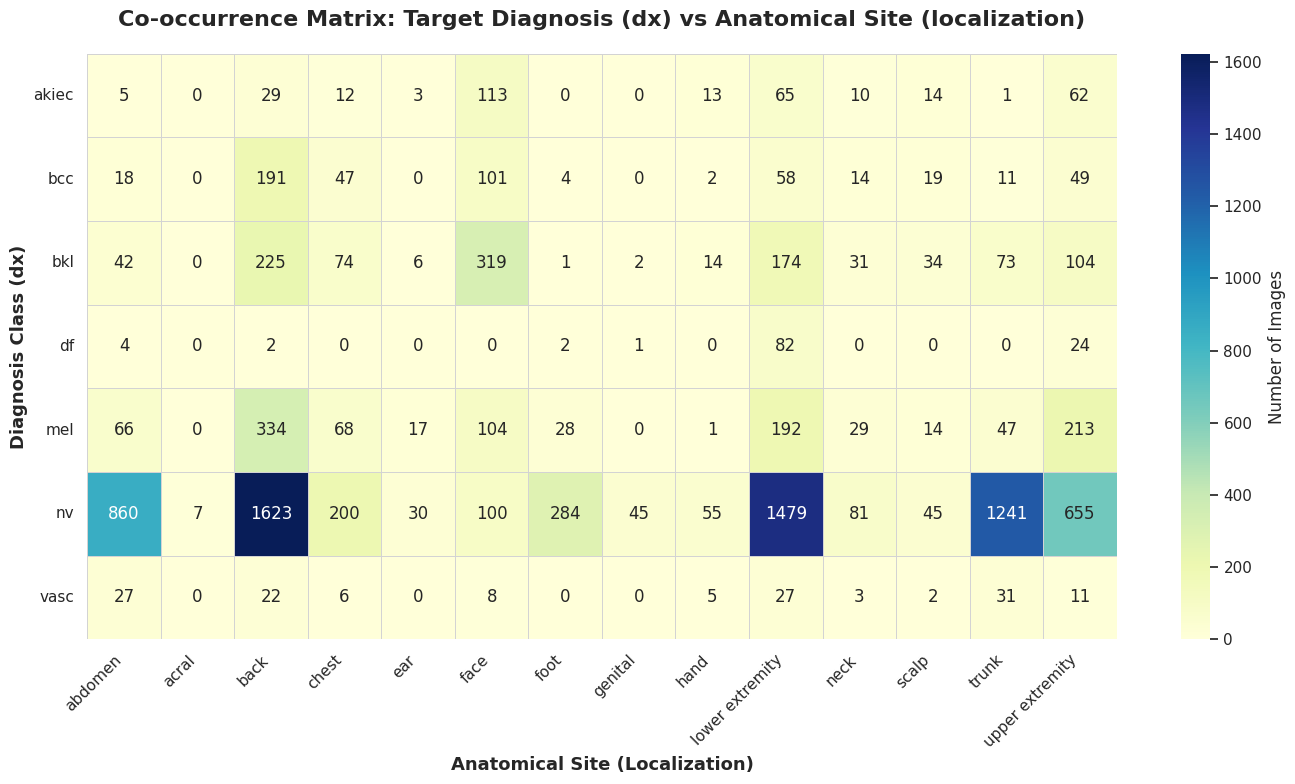

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Generate  Co-occurrence Matrix (Cross-tabulation)
co_matrix = pd.crosstab(df_clean['dx'], df_clean['localization'])

plt.figure(figsize=(14, 8))
sns.set_theme(style="white")

# 2. Plot the Heatmap
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlGnBu', 
            linewidths=0.5, linecolor='lightgray', 
            cbar_kws={'label': 'Number of Images'})

# 3. Formatting labels and titles
plt.title('Co-occurrence Matrix: Target Diagnosis (dx) vs Anatomical Site (localization)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Anatomical Site (Localization)', fontsize=13, fontweight='bold')
plt.ylabel('Diagnosis Class (dx)', fontsize=13, fontweight='bold')

# Rotate the x-axis labels so don't overlap
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

#### Spatial Heatmap

Calculating spatial heatmaps. This may take a minute...


Processing Classes:   0%|          | 0/7 [00:00<?, ?it/s]

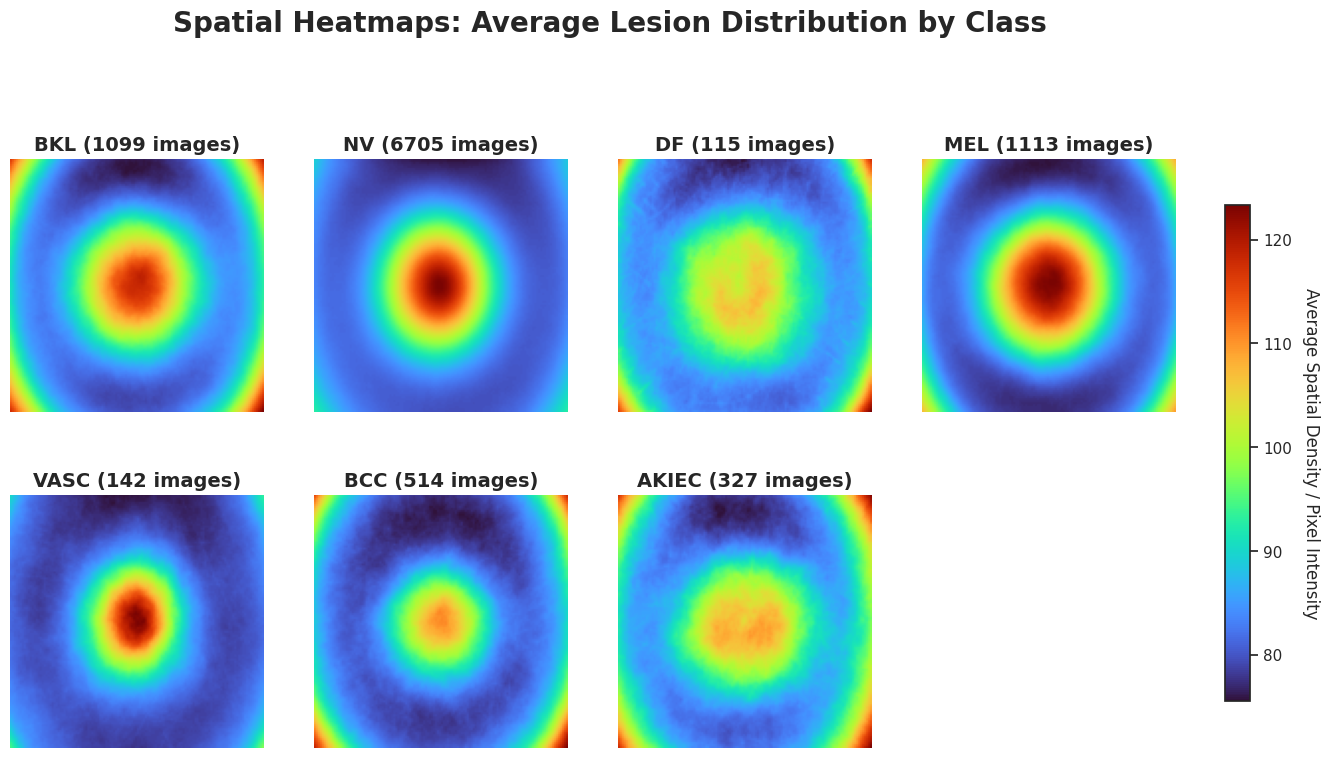

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm # For progress tracking

# 1. Specify target size
HEATMAP_SIZE = (128, 128)

# 2. 7 unique diagnosis classes
dx_classes = df_clean['dx'].unique()

# 3. Plotting grid (2 rows, 4 columns for 7 classes)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

print("Calculating spatial heatmaps.")

# 4. Calculate the average pixel intensity
for idx, dx_class in enumerate(tqdm(dx_classes, desc="Processing Classes")):
    # Filter image IDs 
    class_images = df_clean[df_clean['dx'] == dx_class]['image_id'].tolist()
    
  
    running_sum = np.zeros(HEATMAP_SIZE)
    valid_count = 0
    
    # Process each image in the class
    for img_id in class_images:
        img_path = image_path_map.get(img_id) # Uses your existing image_path_map
        if img_path and os.path.exists(img_path):
            try:
                
                with Image.open(img_path) as img:
                    img_gray = img.convert('L').resize(HEATMAP_SIZE, Image.Resampling.BILINEAR)
                    running_sum += np.array(img_gray)
                    valid_count += 1
            except Exception as e:
                pass # Skip corrupted images
                
    # 5. Calculate the average and plot
    if valid_count > 0:
        avg_img = running_sum / valid_count
        
        ax = axes[idx]
        # Invert image so dark lesions appear as "hot" spots
        inverted_avg = 255 - avg_img 
        
        
        im = ax.imshow(inverted_avg, cmap='turbo') 
        ax.set_title(f'{dx_class.upper()} ({valid_count} images)', fontsize=14, fontweight='bold')
        ax.axis('off')

# 6. Clean up the grid 
fig.delaxes(axes[7])


cbar = fig.colorbar(im, ax=axes.tolist(), fraction=0.02, pad=0.04)
cbar.set_label('Average Spatial Density / Pixel Intensity', rotation=270, labelpad=20, fontsize=12)

plt.suptitle('Spatial Heatmaps: Average Lesion Distribution by Class', fontsize=20, fontweight='bold', y=1.05)
plt.show()

#### Spatial Heatmap v2

In [ ]:
# Spatial heatmap per lesion class
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings("ignore")

# Folders for HAM10000 images
image_root_dirs = [
    "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1",
    "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2"
]

# Standardise images for the heatmap grid 
TARGET_SIZE = (224, 224)

# Gaussian smoothing 
GAUSSIAN_SIGMA = 12


if 'image_path_map' not in globals():
    image_path_map = {}
    for root in image_root_dirs:
        if not os.path.isdir(root):
            continue
        for fname in os.listdir(root):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_id = os.path.splitext(fname)[0]
                image_path_map[image_id] = os.path.join(root, fname)

if 'df_clean' not in globals():
    raise RuntimeError("df_clean not found. Make sure your cleaned metadata DataFrame is named df_clean and loaded.")

df_images = df_clean[df_clean['image_id'].isin(image_path_map.keys())].copy()
print(f"Records with available image files: {len(df_images)}")

def compute_centroid_from_image(path, target_size=TARGET_SIZE, min_contour_area=30):
    img = cv2.imread(path)
    if img is None:
        return target_size[0] // 2, target_size[1] // 2

    img_resized = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if np.mean(gray[th == 255]) > np.mean(gray[th == 0]):
        th = cv2.bitwise_not(th)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    th_clean = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel, iterations=1)
    th_clean = cv2.morphologyEx(th_clean, cv2.MORPH_CLOSE, kernel, iterations=1)

    contours, _ = cv2.findContours(th_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return target_size[0] // 2, target_size[1] // 2

    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    if cv2.contourArea(contours[0]) < min_contour_area:
        return target_size[0] // 2, target_size[1] // 2

    M = cv2.moments(contours[0])
    if M['m00'] == 0:
        cx = int(np.mean(contours[0][:, 0, 0]))
        cy = int(np.mean(contours[0][:, 0, 1]))
    else:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])

    cx = np.clip(cx, 0, target_size[0] - 1)
    cy = np.clip(cy, 0, target_size[1] - 1)
    return cx, cy

# Centroid-density heatmap for each class
classes = sorted(df_images['dx'].unique())
class_heatmaps = {}

for cls in classes:
    ids = df_images[df_images['dx'] == cls]['image_id'].unique()
    heat = np.zeros((TARGET_SIZE[1], TARGET_SIZE[0]), dtype=np.float32)
    processed = 0

    for iid in tqdm(ids, desc=f"Processing {cls}", leave=False):
        path = image_path_map.get(iid)
        if not path or not os.path.isfile(path):
            continue
        cx, cy = compute_centroid_from_image(path)
        heat[cy, cx] += 1.0
        processed += 1

    heat_smooth = gaussian_filter(heat, sigma=GAUSSIAN_SIGMA)
    heat_norm = heat_smooth / heat_smooth.max() if heat_smooth.max() > 0 else heat_smooth
    class_heatmaps[cls] = (heat_norm, processed)

# Plot all classes together in one grid
n = len(classes)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    heat_norm, processed = class_heatmaps[cls]
    ax = axes[idx]
    im = ax.imshow(heat_norm, cmap='magma', origin='upper')
    ax.set_title(f"{cls.upper()} ({processed} images)", fontsize=12, fontweight='bold')
    ax.axis('off')

for ax in axes[n:]:
    fig.delaxes(ax)

cbar = fig.colorbar(im, ax=axes[:n].tolist(), fraction=0.02, pad=0.04)
cbar.set_label('Relative density', rotation=270, labelpad=20, fontsize=12)

plt.suptitle('Spatial Heatmaps v2: Segmented Lesion Centroid Density by Class', fontsize=18, fontweight='bold', y=1.02)
plt.show()


Found 10015 image files in provided folders.
Records in df_clean with available image files: 10015
Classes to process: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


Saved heatmap for akiec -> heatmaps_output/heatmap_akiec.png


Saved heatmap for bcc -> heatmaps_output/heatmap_bcc.png


Saved heatmap for bkl -> heatmaps_output/heatmap_bkl.png


Saved heatmap for df -> heatmaps_output/heatmap_df.png


Saved heatmap for mel -> heatmaps_output/heatmap_mel.png


Saved heatmap for nv -> heatmaps_output/heatmap_nv.png


Saved heatmap for vasc -> heatmaps_output/heatmap_vasc.png
Done. Heatmaps saved to: heatmaps_output


#### Clinical: Diagnosis Method (dx_type) - Bar Chart

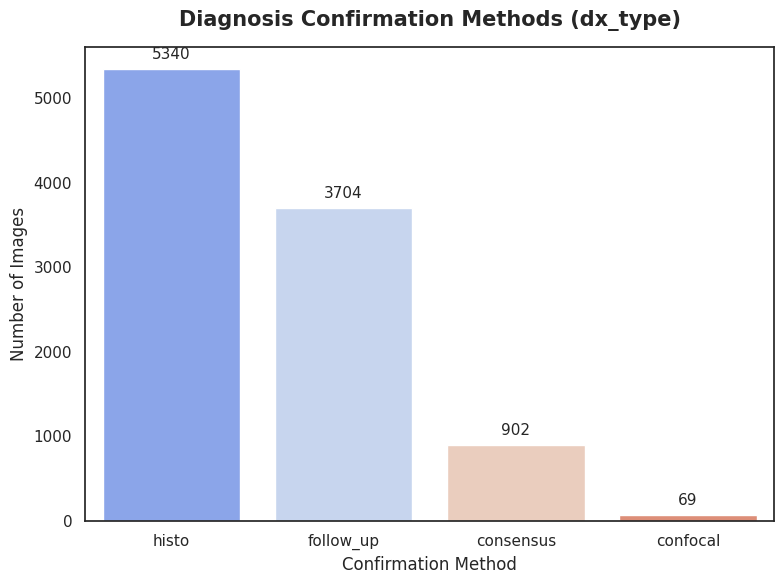

In [46]:
plt.figure(figsize=(8, 6))

ax = sns.countplot(data=df_clean, x='dx_type', 
                   order=df_clean['dx_type'].value_counts().index, 
                   palette="coolwarm")

plt.title('Diagnosis Confirmation Methods (dx_type)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Confirmation Method', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

####  Demographic: Age - Histogram with KDE

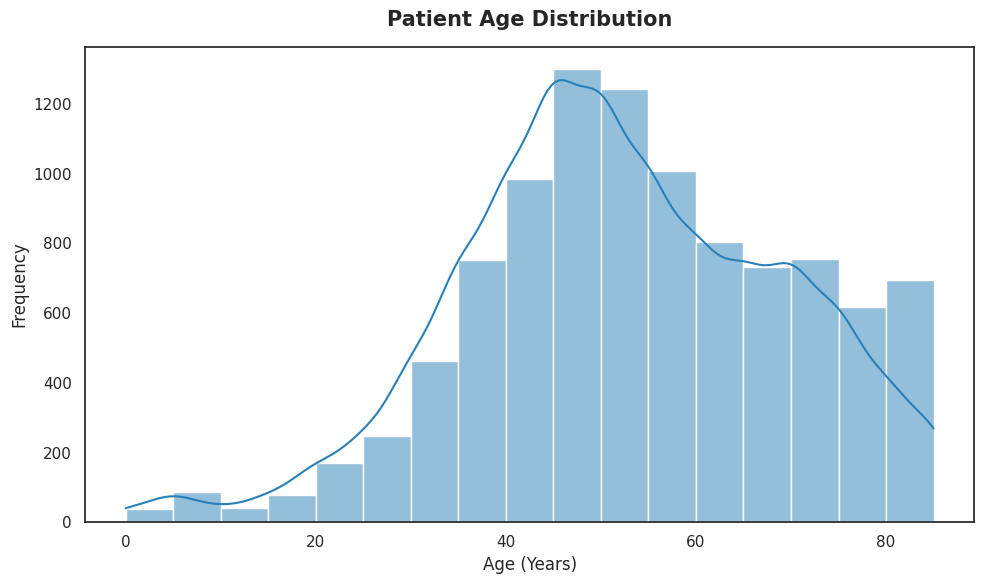

In [47]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df_clean, x='age', bins=17, kde=True, color='#2980b9')

plt.title('Patient Age Distribution', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

####  Demographic: Sex - Pie Chart

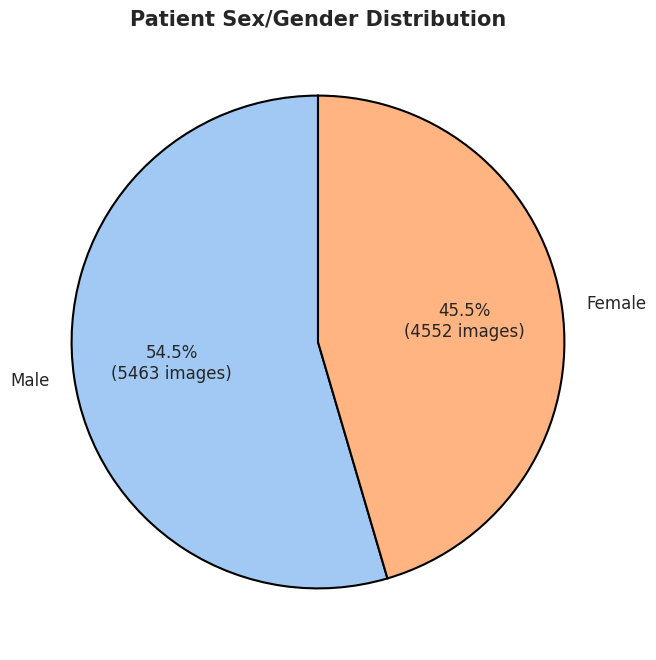

In [48]:
plt.figure(figsize=(8, 8))

sex_counts = df_clean['sex'].value_counts()

# Create a custom formatting function for the pie chart labels
def format_autopct(pct, all_values):
    # Calculate the exact number of images back from the percentage
    absolute_count = int(round(pct / 100.0 * sum(all_values)))
    # Return a formatted string with percentage on top, and count in brackets below
    return f"{pct:.1f}%\n({absolute_count} images)"

# Generate the pie chart
plt.pie(sex_counts, 
        labels=sex_counts.index.str.capitalize(), 
        autopct=lambda pct: format_autopct(pct, sex_counts), # Use the custom function here
        startangle=90, 
        colors=sns.color_palette("pastel")[0:2], 
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.5}, 
        textprops={'fontsize': 12})

plt.title('Patient Sex/Gender Distribution', fontsize=15, fontweight='bold')
plt.show()


#### Clinical: Localization - Horizontal Bar Chart

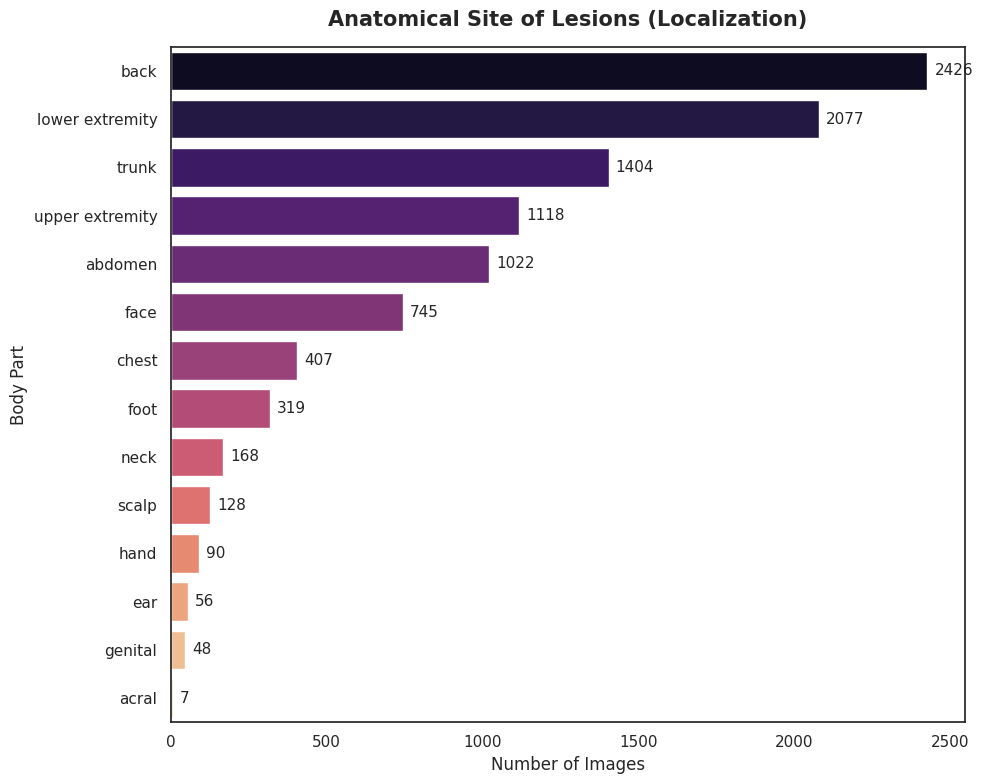

In [49]:
plt.figure(figsize=(10, 8))

ax = sns.countplot(data=df_clean, y='localization', 
                   order=df_clean['localization'].value_counts().index, 
                   palette="magma")

plt.title('Anatomical Site of Lesions (Localization)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Body Part', fontsize=12)

# Add value labels to the right of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=11, xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

## SECTION 3: Hybrid Data-Centric Preprocessing Framework

Implements and evaluates the three preprocessing components used to reduce demographic bias in the HAM10000 dataset: intersectional stratified sampling, adaptive distribution-aware reweighting, and quality-controlled cGAN augmentation for the rarest demographic subgroups.

This section continues directly from the cleaned dataframe produced in Section 2

### Phase 1 — Preprocessing Framework & Phase 2 — cGAN Training

# Phase 1

# Library Imports

In [50]:
import sys, io


import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.preprocessing import LabelEncoder
from collections import Counter

warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("[OK] Libraries imported successfully.")

[OK] Libraries imported successfully.


# Configuration 

In [51]:
# Kaggle path configuration
import os
from pathlib import Path

BASE_KAGGLE   = Path("/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000")
METADATA_PATH = BASE_KAGGLE / "HAM10000_metadata.csv"
IMAGE_DIR_PART1 = BASE_KAGGLE / "HAM10000_images_part_1"
IMAGE_DIR_PART2 = BASE_KAGGLE / "HAM10000_images_part_2"

OUTPUT_DIR = Path("/kaggle/working/phase1_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SPLITS_DIR = OUTPUT_DIR / "splits"
SPLITS_DIR.mkdir(exist_ok=True)

IMG_SIZE = (224, 224)
print(f"[OK] Kaggle paths set. Dataset at: {BASE_KAGGLE}")
print(f"[OK] Outputs -> {OUTPUT_DIR}")


[OK] Kaggle paths set. Dataset at: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000
[OK] Outputs -> /kaggle/working/phase1_outputs


# Load & Validate Dataset

In [ ]:
assert 'df_clean' in globals(), "df_clean not found — run Part A (EDA & Pre-processing) first."
df = df_clean.copy()
print(f"Continuing from Part A's df_clean: {df.shape[0]} records, {df.shape[1]} columns")


missing_images = (~df["image_exists"]).sum()
print(f"[OK] Metadata rows with found images   : {df['image_exists'].sum()}")
print(f"[WARN] Metadata rows with MISSING images : {missing_images}")

df = df[df["image_exists"]].copy()
print(f"\n[CHART] Working dataset (images confirmed): {len(df)} records")

Continuing from Part A's df_clean: 10015 records, 13 columns
[OK] Metadata rows with found images   : 10015
[WARN] Metadata rows with MISSING images : 0

[CHART] Working dataset (images confirmed): 10015 records


# Data Cleaning Verification

In [ ]:
print("=" * 55)
print("  DATA QUALITY CHECK (cleaned upstream in Part A)")
print("=" * 55)
print(df[["age", "sex", "localization"]].isnull().sum())

unknown_sex_remaining = (df["sex"] == "unknown").sum()
unknown_loc_remaining = (df["localization"] == "unknown").sum()
print(f"\n'unknown' sex values remaining          : {unknown_sex_remaining}")
print(f"'unknown' localization values remaining : {unknown_loc_remaining}")

assert unknown_sex_remaining == 0, "Unexpected 'unknown' sex values — check Part A imputation."
assert unknown_loc_remaining == 0, "Unexpected 'unknown' localization values — check Part A imputation."

print(f"\n[OK] Confirmed clean. Final dataset: {len(df)} records")

  DATA QUALITY CHECK (cleaned upstream in Part A)
age             0
sex             0
localization    0
dtype: int64

'unknown' sex values remaining          : 0
'unknown' localization values remaining : 0

[OK] Confirmed clean. Final dataset: 10015 records


#  Create Engineered Features

In [ ]:
# Map dx codes to full names
dx_mapping = {
    "akiec": "Actinic Keratoses",
    "bcc"  : "Basal Cell Carcinoma",
    "bkl"  : "Benign Keratosis",
    "df"   : "Dermatofibroma",
    "mel"  : "Melanoma",
    "nv"   : "Melanocytic Nevi",
    "vasc" : "Vascular Lesions"
}
df["dx_full"] = df["dx"].map(dx_mapping)

# Create age groups (4 clinical bins)
#   Pediatric   : < 18
#   Young Adult : 18 - 39
#   Middle-Aged : 40 - 59
#   Elderly     : 60+

def assign_age_group(age):
    if age < 18:
        return "Pediatric"
    elif age < 40:
        return "YoungAdult"
    elif age < 60:
        return "MiddleAged"
    else:
        return "Elderly"

df["age_group"] = df["age"].apply(assign_age_group)

# Standardise sex labels
df["sex"] = df["sex"].str.lower().str.strip()

# Simplify localization into broader anatomical zones
loc_zone_map = {
    "back"          : "Trunk",
    "lower extremity": "LowerExtremity",
    "trunk"         : "Trunk",
    "upper extremity": "UpperExtremity",
    "abdomen"       : "Trunk",
    "face"          : "Head",
    "chest"         : "Trunk",
    "foot"          : "LowerExtremity",
    "unknown"       : "Unknown",
    "neck"          : "Head",
    "scalp"         : "Head",
    "hand"          : "UpperExtremity",
    "ear"           : "Head",
    "genital"       : "Trunk",
    "acral"         : "LowerExtremity"
}
df["loc_zone"] = df["localization"].map(loc_zone_map).fillna("Other")

# Create the intersectional key (core of Preprocessing Component 1)
#   Key = age_group|sex|loc_zone
#   e.g.  "Elderly|male|Trunk" , "Pediatric|female|Head"
df["intersectional_key"] = (
    df["age_group"] + "|" + df["sex"] + "|" + df["loc_zone"]
)

print("[OK] Feature engineering complete.")
print(f"\nUnique dx classes    : {df['dx'].nunique()}")
print(f"Unique age groups    : {df['age_group'].nunique()} -> {sorted(df['age_group'].unique())}")
print(f"Unique sex values    : {df['sex'].nunique()} -> {df['sex'].unique().tolist()}")
print(f"Unique loc zones     : {df['loc_zone'].nunique()} -> {sorted(df['loc_zone'].unique())}")
print(f"Unique intersect keys: {df['intersectional_key'].nunique()}")

print(df[["image_id","dx","age_group","sex","loc_zone","intersectional_key"]].head(8))

[OK] Feature engineering complete.

Unique dx classes    : 7
Unique age groups    : 4 -> ['Elderly', 'MiddleAged', 'Pediatric', 'YoungAdult']
Unique sex values    : 2 -> ['male', 'female']
Unique loc zones     : 4 -> ['Head', 'LowerExtremity', 'Trunk', 'UpperExtremity']
Unique intersect keys: 32
       image_id   dx age_group   sex loc_zone intersectional_key
0  ISIC_0027419  bkl   Elderly  male     Head  Elderly|male|Head
1  ISIC_0025030  bkl   Elderly  male     Head  Elderly|male|Head
2  ISIC_0026769  bkl   Elderly  male     Head  Elderly|male|Head
3  ISIC_0025661  bkl   Elderly  male     Head  Elderly|male|Head
4  ISIC_0031633  bkl   Elderly  male     Head  Elderly|male|Head
5  ISIC_0027850  bkl   Elderly  male     Head  Elderly|male|Head
6  ISIC_0029176  bkl   Elderly  male     Head  Elderly|male|Head
7  ISIC_0029068  bkl   Elderly  male     Head  Elderly|male|Head


# *** Baseline Bias Audit

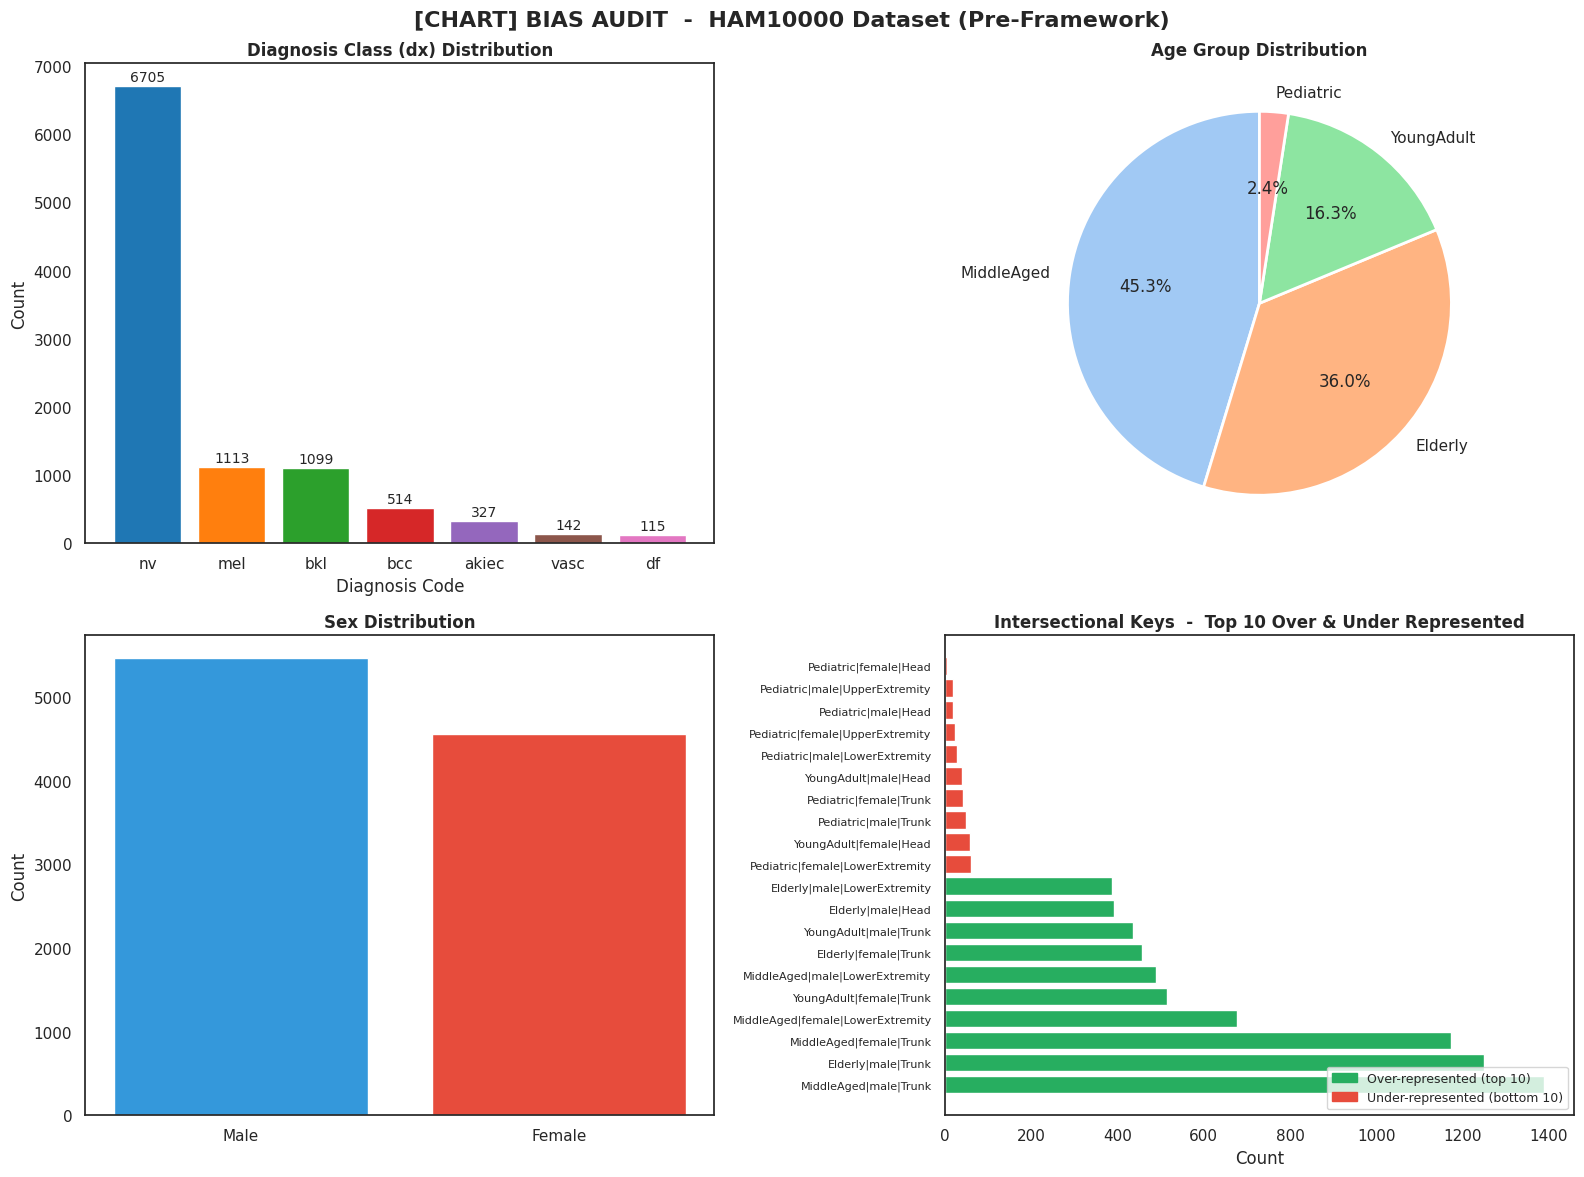

[OK] Bias audit chart saved -> /kaggle/working/phase1_outputs/bias_audit_pre_framework.png


In [55]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Bias Audit — HAM10000 Dataset (Pre-Framework)", fontsize=16, fontweight="bold")

# Plot 1: Class distribution
ax = axes[0, 0]
dx_counts = df["dx"].value_counts()
bars = ax.bar(dx_counts.index, dx_counts.values,
              color=sns.color_palette("tab10", len(dx_counts)))
ax.set_title("Diagnosis Class (dx) Distribution", fontweight="bold")
ax.set_xlabel("Diagnosis Code")
ax.set_ylabel("Count")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(bar.get_height()), ha="center", va="bottom", fontsize=10)

# Plot 2: Age group distribution
ax = axes[0, 1]
age_counts = df["age_group"].value_counts()
ax.pie(age_counts, labels=age_counts.index, autopct="%1.1f%%",
       colors=sns.color_palette("pastel", len(age_counts)), startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title("Age Group Distribution", fontweight="bold")

# Plot 3: Sex distribution
ax = axes[1, 0]
sex_counts = df["sex"].value_counts()
ax.bar(sex_counts.index.str.capitalize(), sex_counts.values,
       color=["#3498db", "#e74c3c"])
ax.set_title("Sex Distribution", fontweight="bold")
ax.set_ylabel("Count")

# Plot 4: Intersectional key — top 20 most/least represented
ax = axes[1, 1]
key_counts = df["intersectional_key"].value_counts()
top_keys = pd.concat([key_counts.head(10), key_counts.tail(10)])
colors = ["#27ae60"] * 10 + ["#e74c3c"] * 10
ax.barh(range(len(top_keys)), top_keys.values, color=colors)
ax.set_yticks(range(len(top_keys)))
ax.set_yticklabels(top_keys.index, fontsize=8)
ax.set_title("Intersectional Keys  -  Top 10 Over & Under Represented", fontweight="bold")
ax.set_xlabel("Count")
# Legend
over_patch  = mpatches.Patch(color="#27ae60", label="Over-represented (top 10)")
under_patch = mpatches.Patch(color="#e74c3c", label="Under-represented (bottom 10)")
ax.legend(handles=[over_patch, under_patch], loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bias_audit_pre_framework.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[OK] Bias audit chart saved -> {OUTPUT_DIR / 'bias_audit_pre_framework.png'}")

# *** Component 1: Intersectional Stratified Sampling

  STEP 1.2  -  INTERSECTIONAL STRATIFIED SAMPLING
Classes (encoded 0-6): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

[WARN]  11 singleton strat_key groups found.
   These will be kept in training set only (cannot be split).

Splittable records: 10004
Singleton records   : 11

[CHART] SPLIT SUMMARY:
  Training set  :  7042 records (70.3%)
  Validation set:  1486 records (14.8%)
  Test set      :  1487 records (14.8%)
  Total         : 10015 records

[CHART] CLASS DISTRIBUTION ACROSS SPLITS (%):
       Full Dataset  Train Split  Val Split  Test Split
dx                                                     
akiec          3.27         3.31       3.36        2.96
bcc            5.13         5.18       4.98        5.04
bkl           10.97        10.96      10.90       11.10
df             1.15         1.19       1.14        0.94
mel           11.11        11.09      11.10       11.23
nv            66.95        66.67      67.43       67.79
vasc           1.42         1.59       1.08  

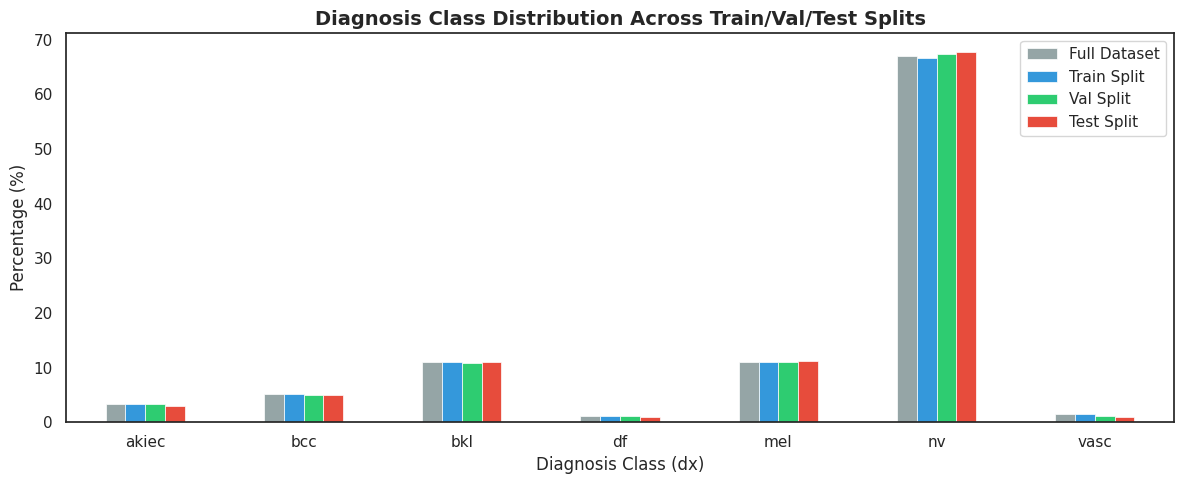

[OK] Split distribution chart saved.


In [ ]:
print("=" * 60)
print("  Component 1  -  INTERSECTIONAL STRATIFIED SAMPLING")
print("=" * 60)

# Encode the target (dx) for stratification
le_dx = LabelEncoder()
df["dx_encoded"] = le_dx.fit_transform(df["dx"])

# Store class name mapping
class_names = list(le_dx.classes_)
print(f"Classes (encoded 0-{len(class_names)-1}): {class_names}")

# Build a combined stratification key: dx + intersectional_key
#  Split is balanced across diagnosis AND demographics
df["strat_key"] = df["dx"] + "__" + df["intersectional_key"]

# Some rare strat_key combos may have only 1 sample (Cannot split)
# Identify and handle singleton groups
strat_counts = df["strat_key"].value_counts()
singleton_keys = strat_counts[strat_counts == 1].index.tolist()

if singleton_keys:
    print(f"\n[WARN]  {len(singleton_keys)} singleton strat_key groups found.")
    print("   These will be kept in training set only (cannot be split).")
    df_singletons = df[df["strat_key"].isin(singleton_keys)].copy()
    df_splittable = df[~df["strat_key"].isin(singleton_keys)].copy()
else:
    df_singletons = pd.DataFrame()
    df_splittable = df.copy()

print(f"\nSplittable records: {len(df_splittable)}")
print(f"Singleton records   : {len(df_singletons)}")

# Perform the stratified split: 70% train / 15% val / 15% test

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_SEED)
train_idx, temp_idx = next(sss1.split(df_splittable, df_splittable["strat_key"]))

df_train = df_splittable.iloc[train_idx].copy()
df_temp  = df_splittable.iloc[temp_idx].copy()

# Handle singleton strat_keys in df_temp for second split
strat_counts_temp = df_temp["strat_key"].value_counts()
singleton_temp    = strat_counts_temp[strat_counts_temp == 1].index.tolist()
df_temp_singletons = df_temp[df_temp["strat_key"].isin(singleton_temp)].copy()
df_temp_splittable = df_temp[~df_temp["strat_key"].isin(singleton_temp)].copy()

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=RANDOM_SEED)
val_idx, test_idx = next(sss2.split(df_temp_splittable, df_temp_splittable["strat_key"]))

df_val  = df_temp_splittable.iloc[val_idx].copy()
df_test = df_temp_splittable.iloc[test_idx].copy()

# Add singletons to training set
df_train = pd.concat([df_train, df_singletons, df_temp_singletons], ignore_index=True)

print(f"\n[CHART] SPLIT SUMMARY:")
print(f"  Training set  : {len(df_train):>5} records ({len(df_train)/len(df)*100:.1f}%)")
print(f"  Validation set: {len(df_val):>5} records ({len(df_val)/len(df)*100:.1f}%)")
print(f"  Test set      : {len(df_test):>5} records ({len(df_test)/len(df)*100:.1f}%)")
print(f"  Total         : {len(df_train)+len(df_val)+len(df_test):>5} records")


# Verify stratification quality
print("\n[CHART] CLASS DISTRIBUTION ACROSS SPLITS (%):")

split_comparison = pd.DataFrame({
    "Full Dataset": df["dx"].value_counts(normalize=True) * 100,
    "Train Split" : df_train["dx"].value_counts(normalize=True) * 100,
    "Val Split"   : df_val["dx"].value_counts(normalize=True) * 100,
    "Test Split"  : df_test["dx"].value_counts(normalize=True) * 100,
}).round(2)
print(split_comparison)

# Visualise split proportions
fig, ax = plt.subplots(figsize=(12, 5))
split_comparison.plot(kind="bar", ax=ax, color=["#95a5a6","#3498db","#2ecc71","#e74c3c"],
                      edgecolor="white", linewidth=0.5)
ax.set_title("Diagnosis Class Distribution Across Train/Val/Test Splits",
             fontweight="bold", fontsize=14)
ax.set_xlabel("Diagnosis Class (dx)")
ax.set_ylabel("Percentage (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stratified_split_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[OK] Split distribution chart saved.")

# *** Component 2: Adaptive Distribution-Aware Reweighting

  STEP 1.3  -  ADAPTIVE DISTRIBUTION-AWARE REWEIGHTING

Weight statistics (training set):
count    7042.0000
mean        1.0000
std         1.9956
min         0.2262
25%         0.2512
50%         0.6397
75%         0.9958
max        44.0125
Name: sample_weight, dtype: float64


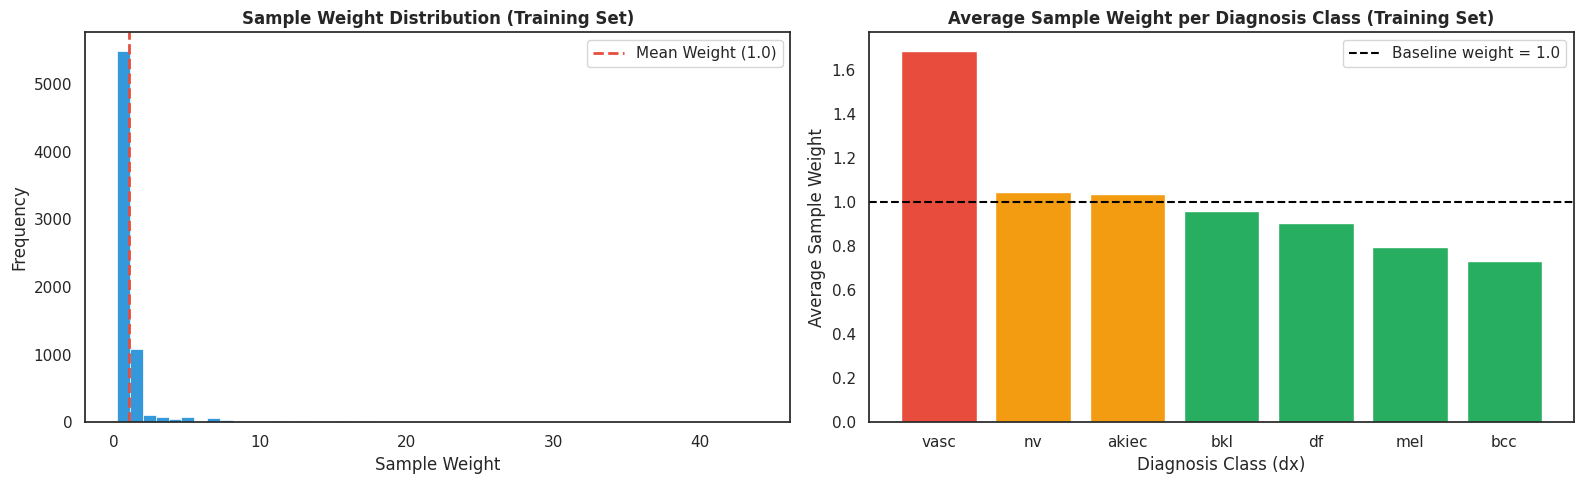


[HIGH] TOP 15 MOST UNDERREPRESENTED SUBGROUPS (highest weights):
                                  Average Weight  Sample Count
intersectional_key                                            
Pediatric|female|Head                  44.012500             5
Pediatric|male|UpperExtremity          16.927885            13
Pediatric|male|Head                    15.718750            14
Pediatric|female|UpperExtremity        12.944853            17
Pediatric|male|LowerExtremity          11.003125            20
YoungAdult|male|Head                    7.335417            30
Pediatric|female|Trunk                  7.098790            31
Pediatric|male|Trunk                    6.472426            34
YoungAdult|female|Head                  5.367378            41
Pediatric|female|LowerExtremity         5.239583            42
YoungAdult|male|UpperExtremity          4.401250            50
YoungAdult|female|UpperExtremity        2.895559            76
MiddleAged|female|Head                  2.178837    

In [ ]:
print("=" * 60)
print("  Component 2  -  ADAPTIVE DISTRIBUTION-AWARE REWEIGHTING")
print("=" * 60)

# Compute inverse-frequency weights based on the intersectional key
#   Weight formula:  w_i = N_total / (N_unique_keys × count_of_key_i)
#   Higher weights to rare demographic subgroups

# Compute on the Training Set only (Avoid data leakage)
key_counts_train = df_train["intersectional_key"].value_counts().to_dict()
N_total  = len(df_train)
N_keys   = len(key_counts_train)

df_train["sample_weight"] = df_train["intersectional_key"].map(
    lambda key: N_total / (N_keys * key_counts_train[key])
)

# Normalize weights so the mean = 1.0
mean_weight = df_train["sample_weight"].mean()
df_train["sample_weight"] = df_train["sample_weight"] / mean_weight

print(f"\nWeight statistics (training set):")
print(df_train["sample_weight"].describe().round(4))

# Apply the same weight logic to val/test 
#   If a key exists in val/test, then assign max_train_weight
max_train_weight = df_train["sample_weight"].max()

def compute_weight(key, key_counts, N_total, N_keys, max_w):
    if key in key_counts:
        return (N_total / (N_keys * key_counts[key])) / mean_weight
    return max_w

df_val["sample_weight"]  = df_val["intersectional_key"].apply(
    lambda k: compute_weight(k, key_counts_train, N_total, N_keys, max_train_weight))
df_test["sample_weight"] = df_test["intersectional_key"].apply(
    lambda k: compute_weight(k, key_counts_train, N_total, N_keys, max_train_weight))

# Visualise weight distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Weight histogram
axes[0].hist(df_train["sample_weight"], bins=50, color="#3498db", edgecolor="white",
             linewidth=0.5)
axes[0].axvline(1.0, color="#e74c3c", linestyle="--", linewidth=2, label="Mean Weight (1.0)")
axes[0].set_title("Sample Weight Distribution (Training Set)", fontweight="bold")
axes[0].set_xlabel("Sample Weight")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Average weight per dx class
avg_weight_per_dx = df_train.groupby("dx")["sample_weight"].mean().sort_values(ascending=False)
colors = ["#e74c3c" if w > 1.5 else "#f39c12" if w > 1.0 else "#27ae60"
          for w in avg_weight_per_dx.values]
axes[1].bar(avg_weight_per_dx.index, avg_weight_per_dx.values, color=colors, edgecolor="white")
axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1.5, label="Baseline weight = 1.0")
axes[1].set_title("Average Sample Weight per Diagnosis Class (Training Set)",
                  fontweight="bold")
axes[1].set_xlabel("Diagnosis Class (dx)")
axes[1].set_ylabel("Average Sample Weight")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_weights_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Print top-weighted (most underrepresented) subgroups
print("\n[HIGH] TOP 15 MOST UNDERREPRESENTED SUBGROUPS (highest weights):")
top_underrep = (
    df_train.groupby("intersectional_key")["sample_weight"]
    .agg(["mean","count"])
    .sort_values("mean", ascending=False)
    .head(15)
)
top_underrep.columns = ["Average Weight", "Sample Count"]
print(top_underrep)

print("\n[LOW] TOP 15 MOST OVER-REPRESENTED SUBGROUPS (lowest weights):")
top_overrep = (
    df_train.groupby("intersectional_key")["sample_weight"]
    .agg(["mean","count"])
    .sort_values("mean", ascending=True)
    .head(15)
)
top_overrep.columns = ["Average Weight", "Sample Count"]
print(top_overrep)

# *** Identify Rare Subgroups for cGAN Augmentation

In [ ]:
print("=" * 60)
print("  IDENTIFYING RARE SUBGROUPS -> cGAN Augmentation Targets")
print("=" * 60)

# Define rare subgroup threshold
RARE_THRESHOLD = 30  # subgroups with fewer than 30 training samples

key_counts_df = (
    df_train.groupby(["intersectional_key","dx","age_group","sex","loc_zone"])
    .size()
    .reset_index(name="count")
    .sort_values("count")
)

rare_subgroups = key_counts_df[key_counts_df["count"] < RARE_THRESHOLD].copy()
print(f"\n[TARGET] Found {len(rare_subgroups)} rare subgroups (< {RARE_THRESHOLD} samples):")
print(rare_subgroups)

# Save for cGAN notebook
rare_subgroups.to_csv(OUTPUT_DIR / "rare_subgroups_cgan_targets.csv", index=False)
print(f"\n[OK] Rare subgroups saved -> {OUTPUT_DIR / 'rare_subgroups_cgan_targets.csv'}")

# Summary per dx class
print("\n[CHART] Rare subgroup count per dx class:")
print(rare_subgroups.groupby("dx")["count"].agg(["sum","count"])
        .rename(columns={"sum":"Total samples in rare subgroups",
                         "count":"Number of rare subgroups"}))

  IDENTIFYING RARE SUBGROUPS -> cGAN Augmentation Targets

[TARGET] Found 108 rare subgroups (< 30 samples):
                   intersectional_key     dx   age_group     sex        loc_zone  count
67            MiddleAged|female|Trunk     df  MiddleAged  female           Trunk      1
116              Pediatric|male|Trunk    mel   Pediatric    male           Trunk      1
150    YoungAdult|male|UpperExtremity     df  YoungAdult    male  UpperExtremity      1
72   MiddleAged|female|UpperExtremity    bcc  MiddleAged  female  UpperExtremity      1
137              YoungAdult|male|Head  akiec  YoungAdult    male            Head      1
..                                ...    ...         ...     ...             ...    ...
65            MiddleAged|female|Trunk    bcc  MiddleAged  female           Trunk     27
30        Elderly|male|LowerExtremity  akiec     Elderly    male  LowerExtremity     27
3                 Elderly|female|Head    mel     Elderly  female            Head     27
44        E

#  Save All Processed Splits

In [ ]:
# Save split DataFrames to CSV for use in the cGAN and CNN 
df_train.to_csv(SPLITS_DIR / "train_split.csv", index=False)
df_val.to_csv(  SPLITS_DIR / "val_split.csv",   index=False)
df_test.to_csv( SPLITS_DIR / "test_split.csv",  index=False)

# Save the label encoder mapping
label_map = {cls: int(idx) for idx, cls in enumerate(le_dx.classes_)}
with open(OUTPUT_DIR / "label_map.json", "w") as f:
    json.dump(label_map, f, indent=2)

# Save the intersectional key weight map (for CNN training)
weight_map = df_train.set_index("image_id")["sample_weight"].to_dict()
with open(OUTPUT_DIR / "sample_weights.json", "w") as f:
    json.dump(weight_map, f, indent=2)

print("[OK] ALL PHASE 1 STEP 1 OUTPUTS SAVED:")
print(f"  [DIR] {SPLITS_DIR / 'train_split.csv'}  ({len(df_train)} rows)")
print(f"  [DIR] {SPLITS_DIR / 'val_split.csv'}    ({len(df_val)} rows)")
print(f"  [DIR] {SPLITS_DIR / 'test_split.csv'}   ({len(df_test)} rows)")
print(f"  [DIR] {OUTPUT_DIR / 'label_map.json'}")
print(f"  [DIR] {OUTPUT_DIR / 'sample_weights.json'}")
print(f"  [DIR] {OUTPUT_DIR / 'rare_subgroups_cgan_targets.csv'}")

[OK] ALL PHASE 1 STEP 1 OUTPUTS SAVED:
  [DIR] /kaggle/working/phase1_outputs/splits/train_split.csv  (7042 rows)
  [DIR] /kaggle/working/phase1_outputs/splits/val_split.csv    (1486 rows)
  [DIR] /kaggle/working/phase1_outputs/splits/test_split.csv   (1487 rows)
  [DIR] /kaggle/working/phase1_outputs/label_map.json
  [DIR] /kaggle/working/phase1_outputs/sample_weights.json
  [DIR] /kaggle/working/phase1_outputs/rare_subgroups_cgan_targets.csv


#  Final Summary Report

In [ ]:
print("\n" + "=" * 60)
print("  PHASE 1 -  COMPLETE SUMMARY")
print("=" * 60)

print(f"""
DATASET PREPARATION (Step 1.1):
  |-- Total records loaded           : {len(df):,}
  |-- Images verified & linked       : {len(df):,}
  |-- Missing values handled         : Median (age), Mode (sex, localization)
  `-- Age groups created             : Pediatric / YoungAdult / MiddleAged / Elderly

INTERSECTIONAL STRATIFIED SAMPLING (Component 1):
  |-- Unique intersectional keys     : {df['intersectional_key'].nunique()}
  |-- Training set                   : {len(df_train):,} records
  |-- Validation set                 : {len(df_val):,} records
  `-- Test set                       : {len(df_test):,} records

ADAPTIVE DISTRIBUTION-AWARE REWEIGHTING (Component 2):
  |-- Weight range (training)        : {df_train['sample_weight'].min():.3f} - {df_train['sample_weight'].max():.3f}
  |-- Mean weight (normalised to)    : {df_train['sample_weight'].mean():.3f}
  `-- Rare subgroups for cGAN aug.   : {len(rare_subgroups)} subgroups (< {RARE_THRESHOLD} samples)

NEXT STEP -> Open: phase1_step2_cgan_training.py
""")



  PHASE 1 STEPS 1.1-1.3  -  COMPLETE SUMMARY

DATASET PREPARATION (Step 1.1):
  |-- Total records loaded           : 10,015
  |-- Images verified & linked       : 10,015
  |-- Missing values handled         : Median (age), Mode (sex, localization)
  `-- Age groups created             : Pediatric / YoungAdult / MiddleAged / Elderly

INTERSECTIONAL STRATIFIED SAMPLING (Step 1.2):
  |-- Unique intersectional keys     : 32
  |-- Training set                   : 7,042 records
  |-- Validation set                 : 1,486 records
  `-- Test set                       : 1,487 records

ADAPTIVE DISTRIBUTION-AWARE REWEIGHTING (Step 1.3):
  |-- Weight range (training)        : 0.226 - 44.013
  |-- Mean weight (normalised to)    : 1.000
  `-- Rare subgroups for cGAN aug.   : 108 subgroups (< 30 samples)

NEXT STEP -> Open: phase1_step2_cgan_training.py



# Phase 2

# Component 3 - Quality-Controlled Conditional GAN (cGAN)

# GPU Setup

In [ ]:
# GPU environment setup
# This cell restarts the kernel to load the correct CUDA-matched torch build. (Rerun again)

import subprocess, sys, os

def get_torch_version():
    try:
        import torch
        return torch.__version__
    except Exception:
        return None

REQUIRED_TORCH = '2.2.2'
current = get_torch_version()

if current and current.startswith(REQUIRED_TORCH):
    # Already correct version
    print(f'[OK] torch {current} already installed. No restart needed.')
    print('[OK] You can run the remaining cells directly.')
else:
    print(f'[INFO] Current torch: {current} — installing correct version...')

    # Step 1 — Pin NumPy to 1.x before torch install
    print('[STEP 1] Pinning NumPy < 2.0...')
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install',
        'numpy<2.0', '--quiet'
    ], stderr=subprocess.DEVNULL)
    print('[STEP 1] Done.')

    # Step 2 — Install matching torch for Kaggle P100 GPU (SM 6.0, CUDA 12.1)
    print('[STEP 2] Installing torch 2.2.2+cu121 + torchvision 0.17.2+cu121...')
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install',
        'torch==2.2.2+cu121',
        'torchvision==0.17.2+cu121',
        'scipy',
        '--index-url', 'https://download.pytorch.org/whl/cu121',
        '--quiet'
    ], stderr=subprocess.DEVNULL)
    print('[STEP 2] Install complete.')

    # Step 3 — Kill kernel for clean restart
    # After restart, Rerun again
    print('[STEP 3] Restarting kernel for clean package load...')
    print('When the dialog appears, click OK, then skip this cell and run from the imports cell below.')
    os.kill(os.getpid(), 9)

[OK] torch 2.2.2+cu121 already installed. No restart needed.
[OK] You can run the remaining cells directly.


# Imports

In [ ]:
import sys, io

import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torchvision.models import inception_v3
from scipy import linalg

warnings.filterwarnings("ignore")

# Verify versions are compatible
print(f"torch      : {torch.__version__}")
import torchvision
print(f"torchvision: {torchvision.__version__}")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'  # surface kernel errors at the exact op

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if DEVICE.type == 'cuda':
    gpu_name = torch.cuda.get_device_name(0)
    cuda_ver = torch.version.cuda
    torch_ver = torch.__version__
    print(f'[OK] Device      : {DEVICE}')
    print(f'   GPU           : {gpu_name}')
    print(f'   CUDA version  : {cuda_ver}')
    print(f'   torch version : {torch_ver}')

    try:
        _t = torch.zeros(1).cuda()
        del _t
        print('[OK] CUDA kernel smoke test passed — SM 6.0 support confirmed')
    except Exception as e:
        raise RuntimeError(
            f'CUDA kernel test failed: {e}\n'
            'torch was not built with SM 6.0 support. '
            'Make sure the GPU Environment Setup cell above ran successfully and the kernel was restarted after install.'
        )
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
else:
    raise RuntimeError('No GPU found. Go to Kaggle Settings -> Accelerator -> GPU P100.')


torch      : 2.2.2+cu121
torchvision: 0.17.2+cu121
[OK] Device      : cuda
   GPU           : Tesla P100-PCIE-16GB
   CUDA version  : 12.1
   torch version : 2.2.2+cu121
[OK] CUDA kernel smoke test passed — SM 6.0 support confirmed


# Configuration

In [63]:
# Kaggle path configuration and training settings
from pathlib import Path

OUTPUT_DIR = Path("/kaggle/working/phase1_outputs")
SPLITS_DIR = OUTPUT_DIR / "splits"
CGAN_DIR   = OUTPUT_DIR / "cgan"
SYNTH_DIR  = OUTPUT_DIR / "synthetic_images"

for d in [CGAN_DIR, SYNTH_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE    = 64
LATENT_DIM    = 128
N_CLASSES_DX  = 7
EMBED_DIM     = 32
BATCH_SIZE    = 64
N_EPOCHS      = 200    # cGAN training epochs
LR_G          = 0.0002
LR_D          = 0.0002
BETA1         = 0.5
BETA2         = 0.999
GP_LAMBDA     = 10
N_CRITIC      = 5
SAVE_INTERVAL = 50

AGE_GROUPS = ["Elderly", "MiddleAged", "Pediatric", "YoungAdult"]
SEX_LABELS = ["female", "male"]
LOC_ZONES  = ["Head", "LowerExtremity", "Other", "Trunk", "Unknown", "UpperExtremity"]
DX_CLASSES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

SYNTH_PER_SUBGROUP = 60

print(f"[OK] Config: {N_EPOCHS} epochs, batch={BATCH_SIZE}, image={IMAGE_SIZE}x{IMAGE_SIZE}")

[OK] Config: 200 epochs, batch=64, image=64x64


#  Load Data & Build Encoders

In [ ]:
df_train = pd.read_csv(SPLITS_DIR / "train_split.csv")
rare_subgroups = pd.read_csv(OUTPUT_DIR / "rare_subgroups_cgan_targets.csv")

print(f"Training split loaded: {len(df_train)} records")
print(f"Rare subgroups to augment: {len(rare_subgroups)}")

# - Label encoders 
dx_to_idx  = {v: i for i, v in enumerate(DX_CLASSES)}
age_to_idx = {v: i for i, v in enumerate(AGE_GROUPS)}
sex_to_idx = {v: i for i, v in enumerate(SEX_LABELS)}
loc_to_idx = {v: i for i, v in enumerate(LOC_ZONES)}

# Apply to training df
df_train["dx_idx"]  = df_train["dx"].map(dx_to_idx)
df_train["age_idx"] = df_train["age_group"].map(age_to_idx)
df_train["sex_idx"] = df_train["sex"].map(sex_to_idx)
df_train["loc_idx"] = df_train["loc_zone"].map(loc_to_idx)

# Drop any rows with unmapped values
df_train = df_train.dropna(subset=["dx_idx","age_idx","sex_idx","loc_idx"])
df_train = df_train.astype({"dx_idx":"int","age_idx":"int","sex_idx":"int","loc_idx":"int"})

print(f"\ndf_train after encoding: {len(df_train)} records")
print(df_train[["image_id","dx","age_group","sex","loc_zone",
                   "dx_idx","age_idx","sex_idx","loc_idx"]].head(5))

Training split loaded: 7042 records
Rare subgroups to augment: 108

df_train after encoding: 7042 records
       image_id     dx   age_group     sex        loc_zone  dx_idx  age_idx  sex_idx  loc_idx
0  ISIC_0032329  akiec     Elderly  female           Trunk       0        0        0        3
1  ISIC_0026685     nv     Elderly  female  LowerExtremity       5        0        0        1
2  ISIC_0027628     nv  MiddleAged    male  LowerExtremity       5        1        1        1
3  ISIC_0027749     nv  MiddleAged  female  LowerExtremity       5        1        0        1
4  ISIC_0028925    bkl     Elderly  female  LowerExtremity       2        0        0        1


# Dataset Class

In [ ]:
class HAMDermDataset(Dataset):

    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["image_path"]

        try:
            img = Image.open(img_path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (IMAGE_SIZE, IMAGE_SIZE), (128, 128, 128))

        if self.transform:
            img = self.transform(img)

        conditions = {
            "dx"  : torch.tensor(row["dx_idx"],  dtype=torch.long),
            "age" : torch.tensor(row["age_idx"], dtype=torch.long),
            "sex" : torch.tensor(row["sex_idx"], dtype=torch.long),
            "loc" : torch.tensor(row["loc_idx"], dtype=torch.long),
        }
        return img, conditions


# - Transforms
transform_train = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),  # -> [-1, 1]
])

dataset = HAMDermDataset(df_train, transform=transform_train)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=0, pin_memory=True if DEVICE.type=="cuda" else False,
                        drop_last=True)

print(f"[OK] Dataset: {len(dataset)} samples | {len(dataloader)} batches per epoch")

[OK] Dataset: 7042 samples | 110 batches per epoch


#  cGAN Architecture: Condition Embedding Module

In [ ]:
class ConditionEmbedder(nn.Module):

    # Embeds all four condition labels (dx, age, sex, loc) into a single
    # concatenated condition vector used by both Generator and Discriminator.

    def __init__(self, n_dx=N_CLASSES_DX, n_age=len(AGE_GROUPS),
                 n_sex=len(SEX_LABELS), n_loc=len(LOC_ZONES),
                 embed_dim=EMBED_DIM):
        super().__init__()
        self.emb_dx  = nn.Embedding(n_dx,  embed_dim)
        self.emb_age = nn.Embedding(n_age, embed_dim)
        self.emb_sex = nn.Embedding(n_sex, embed_dim)
        self.emb_loc = nn.Embedding(n_loc, embed_dim)
        self.out_dim = embed_dim * 4  # 4 features x embed_dim each

    def forward(self, dx, age, sex, loc):
        return torch.cat([
            self.emb_dx(dx),
            self.emb_age(age),
            self.emb_sex(sex),
            self.emb_loc(loc),
        ], dim=1)


# cGAN Architecture: Generator

In [67]:
class Generator(nn.Module):
    """
    DCGAN-style conditional generator.
    Input : noise vector z (LATENT_DIM) + condition embedding (EMBED_DIM*4)
    Output: RGB image (3 x IMAGE_SIZE x IMAGE_SIZE), values in [-1, 1]
    """
    def __init__(self):
        super().__init__()
        self.embedder = ConditionEmbedder()
        in_dim = LATENT_DIM + self.embedder.out_dim

        # Project + reshape: in_dim -> 512 x 4 x 4
        self.project = nn.Sequential(
            nn.Linear(in_dim, 512 * 4 * 4),
            nn.BatchNorm1d(512 * 4 * 4),
            nn.ReLU(True),
        )

        # Upsample blocks: 4x4 -> 8 -> 16 -> 32 -> 64
        self.conv_blocks = nn.Sequential(
            # 4x4 -> 8x8
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # 8x8 -> 16x16
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # 16x16 -> 32x32
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # 32x32 -> 64x64
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh(),  # output in [-1, 1]
        )

    def forward(self, z, dx, age, sex, loc):
        cond   = self.embedder(dx, age, sex, loc)
        x      = torch.cat([z, cond], dim=1)
        x      = self.project(x)
        x      = x.view(x.size(0), 512, 4, 4)
        return self.conv_blocks(x)


#  cGAN Architecture: Discriminator

In [68]:
class Discriminator(nn.Module):
    """
    DCGAN-style conditional discriminator.
    Input : RGB image (3 x IMAGE_SIZE x IMAGE_SIZE) + projected condition map
    Output: scalar score (higher = more real)  -  unbounded for WGAN-GP
    """
    def __init__(self):
        super().__init__()
        self.embedder = ConditionEmbedder()
        # Project condition into a spatial map (1 x IMAGE_SIZE x IMAGE_SIZE)
        self.cond_proj = nn.Linear(self.embedder.out_dim, IMAGE_SIZE * IMAGE_SIZE)

        # Conv blocks operating on (3+1) = 4 input channels
        self.conv_blocks = nn.Sequential(
            # 64x64 -> 32x32
            nn.Conv2d(4, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 32x32 -> 16x16
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 16x16 -> 8x8
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # 8x8 -> 4x4
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            # 4x4 -> 1x1
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
        )

    def forward(self, img, dx, age, sex, loc):
        cond = self.embedder(dx, age, sex, loc)
        cond_map = self.cond_proj(cond).view(img.size(0), 1, IMAGE_SIZE, IMAGE_SIZE)
        x = torch.cat([img, cond_map], dim=1)  # (B, 4, 64, 64)
        return self.conv_blocks(x).view(img.size(0), -1).mean(1)  # scalar per sample

#  WGAN-GP Gradient Penalty

In [ ]:
def compute_gradient_penalty(D, real_imgs, fake_imgs, dx, age, sex, loc, device):
    """
    WGAN-GP gradient penalty: Enforces the 1-Lipschitz constraint on D.
    Penalises gradients that deviate from norm 1 along interpolated samples.
    """
    B = real_imgs.size(0)
    # Random interpolation coefficient
    alpha = torch.rand(B, 1, 1, 1, device=device)
    interp = (alpha * real_imgs + (1 - alpha) * fake_imgs).requires_grad_(True)

    d_interp = D(interp, dx, age, sex, loc)
    gradients = torch.autograd.grad(
        outputs=d_interp,
        inputs=interp,
        grad_outputs=torch.ones_like(d_interp),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    gradients = gradients.view(B, -1)
    gp = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gp

#  Initialise Models & Optimisers

In [70]:
def weights_init(m):
    """DCGAN weight initialisation: Conv -> N(0, 0.02), BatchNorm -> N(1, 0.02)"""
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G = Generator().to(DEVICE)
D = Discriminator().to(DEVICE)

G.apply(weights_init)
D.apply(weights_init)

opt_G = optim.Adam(G.parameters(), lr=LR_G, betas=(BETA1, BETA2))
opt_D = optim.Adam(D.parameters(), lr=LR_D, betas=(BETA1, BETA2))

# Count parameters
n_params_G = sum(p.numel() for p in G.parameters() if p.requires_grad)
n_params_D = sum(p.numel() for p in D.parameters() if p.requires_grad)
print(f"[OK] Models initialised.")
print(f"   Generator     : {n_params_G:,} trainable parameters")
print(f"   Discriminator : {n_params_D:,} trainable parameters")

# Fixed noise for visual monitoring during training
fixed_noise = torch.randn(16, LATENT_DIM, device=DEVICE)
# Use a varied set of conditions for the fixed samples
fixed_conds = {
    "dx"  : torch.tensor([0,1,2,3,4,5,6,0,1,2,3,4,5,6,0,1], device=DEVICE),
    "age" : torch.tensor([0,1,2,3,0,1,2,3,0,1,2,3,0,1,2,3], device=DEVICE),
    "sex" : torch.tensor([0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1], device=DEVICE),
    "loc" : torch.tensor([0,1,2,3,4,5,0,1,2,3,4,5,0,1,2,3], device=DEVICE),
}


[OK] Models initialised.
   Generator     : 4,878,816 trainable parameters
   Discriminator : 3,293,792 trainable parameters


# *** Training Loop (WGAN-GP)

  TRAINING cGAN (200 epochs, WGAN-GP)
Epoch [   1/200] | D Loss: -33.1428 | G Loss:  55.4572 | GP: 1.0924
Epoch [  10/200] | D Loss: -11.6376 | G Loss:  87.1023 | GP: 0.2836
Epoch [  20/200] | D Loss:  -9.4492 | G Loss:  82.4965 | GP: 0.1783
Epoch [  30/200] | D Loss:  -8.0229 | G Loss:  77.5312 | GP: 0.1346
Epoch [  40/200] | D Loss:  -7.1025 | G Loss:  71.3725 | GP: 0.0912
Epoch [  50/200] | D Loss:  -6.0838 | G Loss:  63.1405 | GP: 0.0665


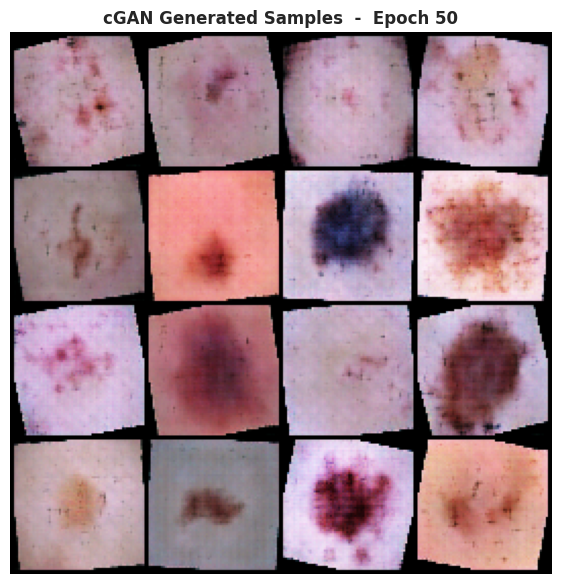

   [OK] Checkpoint saved -> epoch 50
Epoch [  60/200] | D Loss:  -5.5671 | G Loss:  58.4283 | GP: 0.0544
Epoch [  70/200] | D Loss:  -5.1014 | G Loss:  51.0956 | GP: 0.0471
Epoch [  80/200] | D Loss:  -4.4228 | G Loss:  39.5223 | GP: 0.0373
Epoch [  90/200] | D Loss:  -4.1152 | G Loss:  33.1194 | GP: 0.0351
Epoch [ 100/200] | D Loss:  -4.2326 | G Loss:  22.1917 | GP: 0.0333


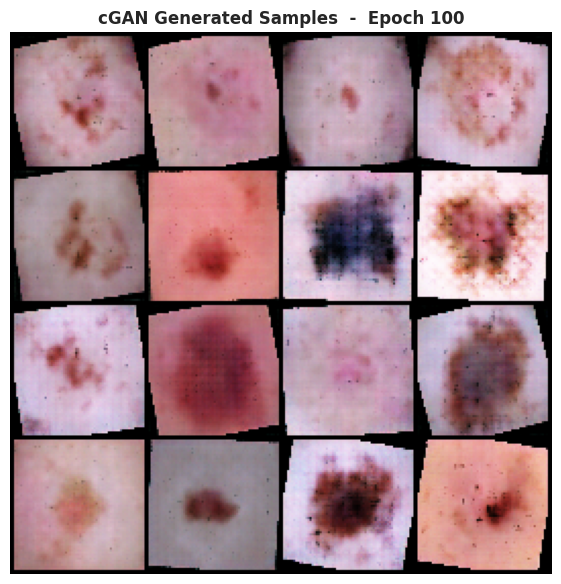

   [OK] Checkpoint saved -> epoch 100
Epoch [ 110/200] | D Loss:  -3.9846 | G Loss:  21.4751 | GP: 0.0323
Epoch [ 120/200] | D Loss:  -3.7412 | G Loss:  13.3007 | GP: 0.0294
Epoch [ 130/200] | D Loss:  -3.6693 | G Loss:   1.1467 | GP: 0.0304
Epoch [ 140/200] | D Loss:  -3.5667 | G Loss:  -7.0201 | GP: 0.0255
Epoch [ 150/200] | D Loss:  -3.5662 | G Loss:  -9.1928 | GP: 0.0271


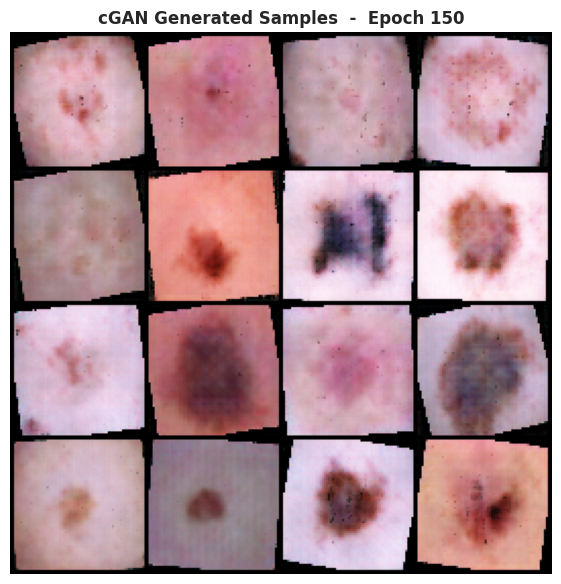

   [OK] Checkpoint saved -> epoch 150
Epoch [ 160/200] | D Loss:  -3.5611 | G Loss: -17.0618 | GP: 0.0271
Epoch [ 170/200] | D Loss:  -3.1299 | G Loss: -17.6232 | GP: 0.0251
Epoch [ 180/200] | D Loss:  -2.9555 | G Loss: -23.9117 | GP: 0.0220
Epoch [ 190/200] | D Loss:  -2.9254 | G Loss: -36.7047 | GP: 0.0206
Epoch [ 200/200] | D Loss:  -2.9655 | G Loss: -41.0232 | GP: 0.0203


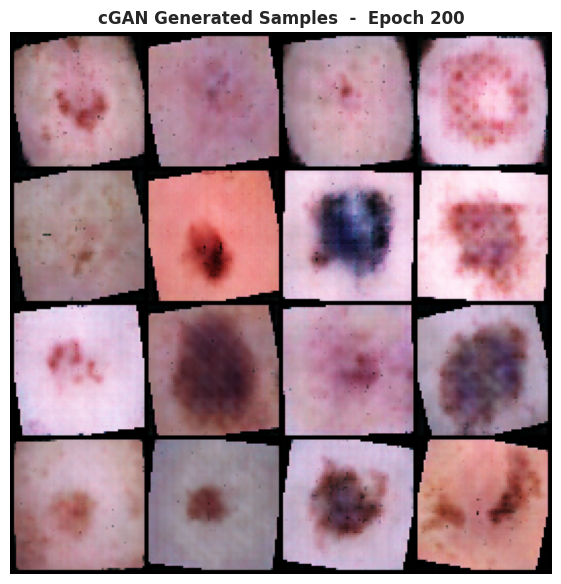

   [OK] Checkpoint saved -> epoch 200

[OK] cGAN training complete. Final models saved.


In [71]:
# - Training history -
history = {"epoch":[], "d_loss":[], "g_loss":[], "gp":[]}

print("=" * 60)
print(f"  TRAINING cGAN ({N_EPOCHS} epochs, WGAN-GP)")
print("=" * 60)

for epoch in range(1, N_EPOCHS + 1):
    G.train(); D.train()
    epoch_d_loss, epoch_g_loss, epoch_gp = 0.0, 0.0, 0.0
    n_batches = 0

    for real_imgs, conds in dataloader:
        real_imgs = real_imgs.to(DEVICE)
        dx  = conds["dx"].to(DEVICE)
        age = conds["age"].to(DEVICE)
        sex = conds["sex"].to(DEVICE)
        loc = conds["loc"].to(DEVICE)
        B   = real_imgs.size(0)

        # - Train Discriminator N_CRITIC times per generator step -
        for _ in range(N_CRITIC):
            z = torch.randn(B, LATENT_DIM, device=DEVICE)
            fake_imgs = G(z, dx, age, sex, loc).detach()

            d_real = D(real_imgs, dx, age, sex, loc)
            d_fake = D(fake_imgs, dx, age, sex, loc)
            gp     = compute_gradient_penalty(D, real_imgs, fake_imgs,
                                              dx, age, sex, loc, DEVICE)
            d_loss = d_fake.mean() - d_real.mean() + GP_LAMBDA * gp

            opt_D.zero_grad()
            d_loss.backward()
            opt_D.step()

        # - Train Generator -
        z = torch.randn(B, LATENT_DIM, device=DEVICE)
        fake_imgs = G(z, dx, age, sex, loc)
        g_loss    = -D(fake_imgs, dx, age, sex, loc).mean()

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        epoch_gp     += gp.item()
        n_batches    += 1

    avg_d = epoch_d_loss / n_batches
    avg_g = epoch_g_loss / n_batches
    avg_gp = epoch_gp / n_batches
    history["epoch"].append(epoch)
    history["d_loss"].append(avg_d)
    history["g_loss"].append(avg_g)
    history["gp"].append(avg_gp)

    # - Logging -
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch [{epoch:>4}/{N_EPOCHS}] | "
              f"D Loss: {avg_d:>8.4f} | G Loss: {avg_g:>8.4f} | GP: {avg_gp:.4f}")

    # - Visualise generated samples -
    if epoch % SAVE_INTERVAL == 0 or epoch == N_EPOCHS:
        G.eval()
        with torch.no_grad():
            sample_imgs = G(fixed_noise,
                            fixed_conds["dx"], fixed_conds["age"],
                            fixed_conds["sex"], fixed_conds["loc"])
        grid = vutils.make_grid(sample_imgs, nrow=4, normalize=True, value_range=(-1,1))
        grid_np = grid.permute(1, 2, 0).cpu().numpy()
        plt.figure(figsize=(10, 6))
        plt.imshow(grid_np)
        plt.axis("off")
        plt.title(f"cGAN Generated Samples  -  Epoch {epoch}", fontweight="bold")
        plt.tight_layout()
        plt.savefig(CGAN_DIR / f"samples_epoch_{epoch:04d}.png", dpi=120, bbox_inches="tight")
        plt.show()

        # Save checkpoint
        torch.save({"epoch": epoch,
                    "G_state": G.state_dict(),
                    "D_state": D.state_dict(),
                    "opt_G": opt_G.state_dict(),
                    "opt_D": opt_D.state_dict()},
                   CGAN_DIR / f"checkpoint_epoch_{epoch:04d}.pt")
        print(f"   [OK] Checkpoint saved -> epoch {epoch}")

# Save final model
torch.save(G.state_dict(), CGAN_DIR / "generator_final.pt")
torch.save(D.state_dict(), CGAN_DIR / "discriminator_final.pt")
print("\n[OK] cGAN training complete. Final models saved.")

#  Plot Training Losses

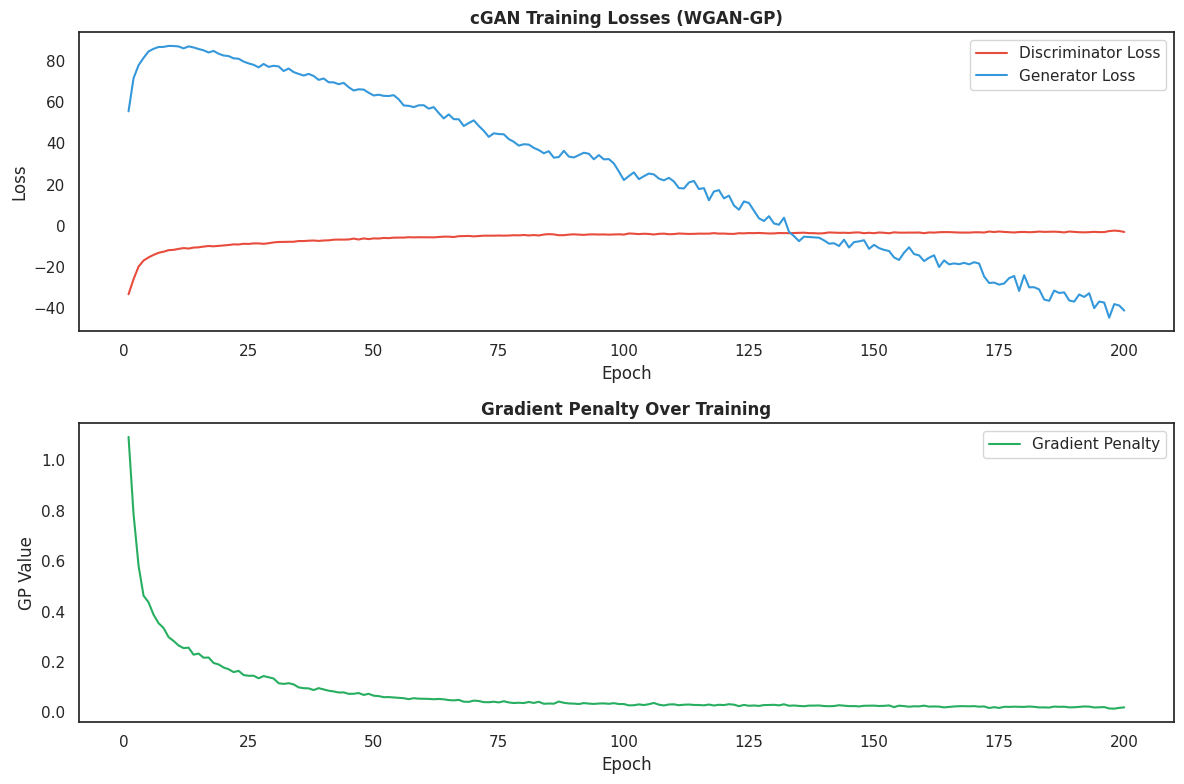

[OK] Loss curves saved.


In [72]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(history["epoch"], history["d_loss"], label="Discriminator Loss", color="#e74c3c")
ax1.plot(history["epoch"], history["g_loss"], label="Generator Loss",     color="#3498db")
ax1.set_title("cGAN Training Losses (WGAN-GP)", fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend()

ax2.plot(history["epoch"], history["gp"], label="Gradient Penalty", color="#27ae60")
ax2.set_title("Gradient Penalty Over Training", fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("GP Value"); ax2.legend()

plt.tight_layout()
plt.savefig(CGAN_DIR / "training_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Loss curves saved.")

# FID Score Helper (Quality Filter)

In [ ]:
def compute_fid_score(real_features, fake_features):
    """
    Frechet Inception Distance between real and generated image distributions.
    Lower FID = better quality (closer to real distribution).
    """
    mu1, sigma1 = real_features.mean(0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = fake_features.mean(0), np.cov(fake_features, rowvar=False)

    diff = mu1 - mu2
    # Matrix square root of sigma1 and sigma2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)
    return float(fid)


def extract_inception_features(imgs_tensor, inception_model, device, batch_size=32):
    """
    Pass images through Inception-v3 (pool3 layer) to get 2048-D feature vectors.
    imgs_tensor: (N, 3, H, W) in [-1,1]
    """
    inception_model.eval()
    # Inception expects 299x299
    resize_fn = transforms.Resize((299, 299))
    features = []

    for i in range(0, len(imgs_tensor), batch_size):
        batch = imgs_tensor[i:i+batch_size]
        batch = torch.stack([resize_fn(img) for img in batch]).to(device)
        # Normalise from [-1,1] -> [0,1] -> Inception normalisation
        batch = (batch + 1) / 2
        batch = transforms.Normalize(mean=[0.485,0.456,0.406],
                                     std=[0.229,0.224,0.225])(batch)
        with torch.no_grad():
            feat = inception_model(batch)
        features.append(feat.cpu().numpy())

    return np.concatenate(features, axis=0)


# Load a light Inception model for FID (pool_aux disabled)
print("Loading Inception-v3 for FID computation...")
inception = inception_v3(pretrained=True, transform_input=False)
inception.fc = nn.Identity()  # Use 2048-D pool features instead of 1000-class output
inception.aux_logits = False
inception = inception.to(DEVICE)
print("[OK] Inception-v3 loaded.")

Loading Inception-v3 for FID computation...


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 177MB/s] 


[OK] Inception-v3 loaded.


#  *** Generate Synthetic Images for Rare Subgroups 

In [ ]:
print("=" * 60)
print("  GENERATING SYNTHETIC IMAGES FOR RARE SUBGROUPS")
print("=" * 60)

G.eval()
G.load_state_dict(torch.load(CGAN_DIR / "generator_final.pt", map_location=DEVICE))

# - Extract real image features for FID baseline -
print("\nExtracting real image features for FID baseline...")
real_tensors = []
transform_eval = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
sample_ids = df_train.sample(min(500, len(df_train)), random_state=SEED)["image_path"].tolist()
for p in tqdm(sample_ids, desc="Loading real images"):
    try:
        img = Image.open(p).convert("RGB")
        real_tensors.append(transform_eval(img))
    except:
        pass
real_tensors = torch.stack(real_tensors)
real_features = extract_inception_features(real_tensors, inception, DEVICE)

# Generate images per rare subgroup
generation_log = []

for _, row in tqdm(rare_subgroups.iterrows(), total=len(rare_subgroups),
                   desc="Processing rare subgroups"):
    dx_code   = row["dx"]
    age_grp   = row["age_group"]
    sex_val   = row["sex"]
    loc_zone  = row["loc_zone"]
    key       = row["intersectional_key"]
    existing  = int(row["count"])

    # Skip unknown/unmapped labels
    if any([dx_code not in dx_to_idx, age_grp not in age_to_idx,
            sex_val not in sex_to_idx, loc_zone not in loc_to_idx]):
        print(f"[WARN]  Skipping unmapped subgroup: {key}")
        continue

    # Determine how many images to generate
    n_to_generate = max(SYNTH_PER_SUBGROUP, 60 - existing)

    # Build condition tensors
    dx_t  = torch.tensor([dx_to_idx[dx_code]],  dtype=torch.long, device=DEVICE).repeat(n_to_generate)
    age_t = torch.tensor([age_to_idx[age_grp]], dtype=torch.long, device=DEVICE).repeat(n_to_generate)
    sex_t = torch.tensor([sex_to_idx[sex_val]], dtype=torch.long, device=DEVICE).repeat(n_to_generate)
    loc_t = torch.tensor([loc_to_idx[loc_zone]],dtype=torch.long, device=DEVICE).repeat(n_to_generate)

    # Generate in batches
    generated = []
    with torch.no_grad():
        for start in range(0, n_to_generate, 32):
            end = min(start + 32, n_to_generate)
            z = torch.randn(end - start, LATENT_DIM, device=DEVICE)
            imgs = G(z, dx_t[start:end], age_t[start:end],
                        sex_t[start:end], loc_t[start:end])
            generated.append(imgs.cpu())
    generated = torch.cat(generated, dim=0)

    # FID Quality Filtering 
    fake_features = extract_inception_features(generated, inception, DEVICE)
    fid = compute_fid_score(real_features, fake_features)

    # Accept all if FID is reasonable
    D.eval()
    with torch.no_grad():
        d_scores = D(generated.to(DEVICE), dx_t[:len(generated)],
                     age_t[:len(generated)], sex_t[:len(generated)],
                     loc_t[:len(generated)]).cpu().numpy()

    # Sort by discriminator score (descending = more realistic)
    sorted_indices = np.argsort(d_scores)[::-1].copy()
    # Keep top 50% or at most 40 images
    n_keep = min(40, max(20, len(sorted_indices) // 2))
    keep_indices = sorted_indices[:n_keep]
    accepted_imgs = generated[keep_indices]

    # Save accepted synthetic images
    subgroup_dir = SYNTH_DIR / key.replace("|", "_")
    subgroup_dir.mkdir(parents=True, exist_ok=True)

    for i, img_tensor in enumerate(accepted_imgs):
        # Denormalize from [-1,1] -> [0,255]
        img_np = ((img_tensor.permute(1,2,0).numpy() + 1) / 2 * 255).astype(np.uint8)
        img_pil = Image.fromarray(img_np)
        # Upsample to 224x224 for CNN training compatibility
        img_pil_224 = img_pil.resize((224, 224), Image.BILINEAR)
        save_path = subgroup_dir / f"synth_{key.replace('|','_')}_{i:04d}.jpg"
        img_pil_224.save(save_path, quality=95)

    generation_log.append({
        "intersectional_key": key, "dx": dx_code, "age_group": age_grp,
        "sex": sex_val, "loc_zone": loc_zone,
        "existing_count": existing, "generated": n_to_generate,
        "accepted_after_filter": n_keep, "fid_score": round(fid, 2)
    })
    print(f"  [OK] {key:<40} | generated:{n_to_generate:>3} | "
          f"kept:{n_keep:>3} | FID:{fid:.1f}")

# Save generation log
gen_log_df = pd.DataFrame(generation_log)
gen_log_df.to_csv(OUTPUT_DIR / "cgan_generation_log.csv", index=False)
print(f"\n[OK] Generation complete. Log saved -> {OUTPUT_DIR / 'cgan_generation_log.csv'}")

  GENERATING SYNTHETIC IMAGES FOR RARE SUBGROUPS

Extracting real image features for FID baseline...


Processing rare subgroups:   1%|          | 1/108 [00:16<30:01, 16.83s/it]

  [OK] MiddleAged|female|Trunk                  | generated: 60 | kept: 30 | FID:336.6


Processing rare subgroups:   2%|▏         | 2/108 [00:31<27:35, 15.62s/it]

  [OK] Pediatric|male|Trunk                     | generated: 60 | kept: 30 | FID:294.2


...

  [OK] Elderly|female|Head                      | generated: 60 | kept: 30 | FID:295.5


Processing rare subgroups:  99%|█████████▉| 107/108 [24:34<00:14, 14.40s/it]

  [OK] Elderly|male|UpperExtremity              | generated: 60 | kept: 30 | FID:318.3


Processing rare subgroups: 100%|██████████| 108/108 [24:49<00:00, 13.79s/it]

  [OK] MiddleAged|female|UpperExtremity         | generated: 60 | kept: 30 | FID:299.1

[OK] Generation complete. Log saved -> /kaggle/working/phase1_outputs/cgan_generation_log.csv


# Build Augmented Training Manifest

In [ ]:
# Collect original training images
original_manifest = df_train[["image_id","image_path","dx","age_group",
                               "sex","loc_zone","intersectional_key",
                               "sample_weight"]].copy()
original_manifest["is_synthetic"] = False

# Collect synthetic images
synth_rows = []
for _, row in gen_log_df.iterrows():
    key  = row["intersectional_key"]
    subgroup_dir = SYNTH_DIR / key.replace("|", "_")
    for img_file in subgroup_dir.glob("*.jpg"):
        synth_rows.append({
            "image_id"          : img_file.stem,
            "image_path"        : str(img_file),
            "dx"                : row["dx"],
            "age_group"         : row["age_group"],
            "sex"               : row["sex"],
            "loc_zone"          : row["loc_zone"],
            "intersectional_key": key,
            "sample_weight"     : 1.0,  # synthetic images get baseline weight
            "is_synthetic"      : True,
        })

synth_manifest = pd.DataFrame(synth_rows)

# Combine into augmented training set (v2 dataset)
df_train_augmented = pd.concat([original_manifest, synth_manifest], ignore_index=True)
df_train_augmented.to_csv(SPLITS_DIR / "train_split_augmented_v2.csv", index=False)

print(f"\n[CHART] AUGMENTED TRAINING SET (v2):")
print(f"  Original training images : {len(original_manifest):,}")
print(f"  Synthetic images added   : {len(synth_manifest):,}")
print(f"  Total augmented dataset  : {len(df_train_augmented):,}")
print(f"\n[OK] Augmented manifest saved -> {SPLITS_DIR / 'train_split_augmented_v2.csv'}")

print(f"\n  NEXT STEP -> Open: phase1_step3_cnn_training_evaluation.py")


[CHART] AUGMENTED TRAINING SET (v2):
  Original training images : 7,042
  Synthetic images added   : 3,240
  Total augmented dataset  : 10,282

[OK] Augmented manifest saved -> /kaggle/working/phase1_outputs/splits/train_split_augmented_v2.csv

  NEXT STEP -> Open: phase1_step3_cnn_training_evaluation.py


# Saving All Outputs

In [ ]:
# Final cell (Packages all Phase 1+2 outputs)

import json, shutil, os
from pathlib import Path

OUTPUT_DIR = Path("/kaggle/working/phase1_outputs")

print("=" * 55)
print("  PACKAGING PHASE 1+2 OUTPUTS")
print("=" * 55)

# Verify critical files exist
checks = {
    "train_split.csv"              : OUTPUT_DIR / "splits" / "train_split.csv",
    "val_split.csv"                : OUTPUT_DIR / "splits" / "val_split.csv",
    "test_split.csv"               : OUTPUT_DIR / "splits" / "test_split.csv",
    "train_split_augmented_v2.csv" : OUTPUT_DIR / "splits" / "train_split_augmented_v2.csv",
    "label_map.json"               : OUTPUT_DIR / "label_map.json",
    "rare_subgroups.csv"           : OUTPUT_DIR / "rare_subgroups_cgan_targets.csv",
    "cgan_generation_log.csv"      : OUTPUT_DIR / "cgan_generation_log.csv",
    "sample_weights.json"          : OUTPUT_DIR / "sample_weights.json",
}

all_ok = True
for name, path in checks.items():
    if path.exists():
        size = path.stat().st_size / 1024
        print(f"  [OK] {name:<40} {size:>8.1f} KB")
    else:
        print(f"  [MISSING] {name}")
        all_ok = False

# Count synthetic images
synth_dir = OUTPUT_DIR / "synthetic_images"
n_synth = sum(1 for _ in synth_dir.rglob("*.jpg")) if synth_dir.exists() else 0
print(f"\n  Synthetic images generated: {n_synth:,}")

# Save a path manifest so the next notebook can remap paths
manifest = {
    "phase12_base"          : str(OUTPUT_DIR),
    "splits_dir"            : str(OUTPUT_DIR / "splits"),
    "synthetic_images_dir"  : str(synth_dir),
    "label_map"             : str(OUTPUT_DIR / "label_map.json"),
    "sample_weights"        : str(OUTPUT_DIR / "sample_weights.json"),
    "rare_subgroups"        : str(OUTPUT_DIR / "rare_subgroups_cgan_targets.csv"),
    "cgan_log"              : str(OUTPUT_DIR / "cgan_generation_log.csv"),
    "n_synthetic_images"    : n_synth,
}
with open(OUTPUT_DIR / "phase12_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)
print(f"  [OK] phase12_manifest.json saved")

  PACKAGING PHASE 1+2 OUTPUTS
  [OK] train_split.csv                            1965.5 KB
  [OK] val_split.csv                               415.0 KB
  [OK] test_split.csv                              414.9 KB
  [OK] train_split_augmented_v2.csv               1986.5 KB
  [OK] label_map.json                                0.1 KB
  [OK] rare_subgroups.csv                            6.3 KB
  [OK] cgan_generation_log.csv                       7.8 KB
  [OK] sample_weights.json                         260.9 KB

  Synthetic images generated: 930
  [OK] phase12_manifest.json saved
